# Analisi delle Serie Temporali — Qualità dell'Aria e Ricoveri Respiratori

**Dataset:** `air_quality_health_dataset.csv`  
**Regione:** East (635 osservazioni giornaliere → ~105 settimane dopo resample)

### Pipeline di analisi
1. Caricamento e preprocessing  
2. Filtraggio regione East + resample settimanale  
3. EDA: statistiche per anno/stagione, scatter con lag, correlazioni crociate  
4. Decomposizione stagionale additiva  
5. Test di stazionarietà ADF  
6. Analisi ACF/PACF  
7. Selezione automatica parametri (`auto_arima`, `d=None`, `D=None`)  
8. Train/Test split 80/20  
9. Fit e confronto di **tre** modelli (A, B, C)  
10. Tabella comparativa finale e conclusioni

> ⚠️ **Nota sul dataset:** i dati sono sintetici (generati artificialmente).  
> Le conclusioni epidemiologiche hanno valore metodologico ma non sono generalizzabili a popolazioni reali.


## 0. Setup Google Colab

In [42]:
# Installa le dipendenze non presenti di default in Colab
import subprocess, sys

pkgs = ["pmdarima", "statsmodels"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Upload del dataset (eseguire solo su Colab)
try:
    from google.colab import files
    print("Ambiente Colab rilevato.")
    print("Carica il file 'air_quality_health_dataset.csv' quando richiesto.")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    # Ambiente locale: il CSV deve essere nella stessa cartella del notebook
    DATA_PATH = "air_quality_health_dataset.csv"
    print(f"Ambiente locale — percorso dati: {DATA_PATH}")


Ambiente locale — percorso dati: air_quality_health_dataset.csv


## 1. Importazione librerie

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import jarque_bera, shapiro, pearsonr  # usati nei test di normalità residui e correlazione
import pmdarima as pm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## Funzioni di Utilità


In [44]:
def adf_test_report(series, title):
    """Esegue il test ADF e stampa un report formattato. Restituisce il risultato grezzo."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'─'*70}")
    print(f"TEST ADF: {title}")
    print(f"{'─'*70}")
    print(f"ADF Statistic:        {result[0]:.6f}")
    print(f"p-value:              {result[1]:.6f}")
    print(f"Lags Used:            {result[2]}")
    print(f"Critical Value (1%):  {result[4]['1%']:.6f}")
    print(f"Critical Value (5%):  {result[4]['5%']:.6f}")
    if result[1] < 0.05:
        print("✓ Serie STAZIONARIA (p < 0.05) — H0 rifiutata")
    else:
        print("✗ Serie NON STAZIONARIA (p >= 0.05) — differenziazione necessaria")
    print()
    return result


## 2. Caricamento e Ispezione del Dataset

In [45]:
df = pd.read_csv(DATA_PATH)
df = df[['date', 'region', 'PM2.5', 'NO2', 'O3', 'temperature',
         'humidity', 'wind_speed', 'respiratory_admissions']]
print(f"Shape: {df.shape}")
df.head()


Shape: (3000, 9)


,date,region,PM2.5,NO2,O3,temperature,humidity,wind_speed,respiratory_admissions
0,2020-01-01,East,31.382887,47.654022,32.574682,37.555663,20.542799,5.204995,11
1,2020-01-02,Central,47.094225,50.734127,23.749138,24.900342,27.308785,6.235446,13
2,2020-01-03,East,53.795917,44.986899,35.530851,23.437165,80.055977,5.673999,3
3,2020-01-04,West,88.315315,20.575023,25.277106,22.388200,25.929988,8.496463,6
4,2020-01-05,South,68.348297,38.445776,35.996440,26.881835,34.946343,1.184104,8


In [46]:
df.info()
print("\nValori nulli:")
print(df.isnull().sum())
print("\nDuplicati:", df.duplicated().sum())
print("\nRegioni presenti:")
print(df['region'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   region                  3000 non-null   object 
 2   PM2.5                   3000 non-null   float64
 3   NO2                     3000 non-null   float64
 4   O3                      3000 non-null   float64
 5   temperature             3000 non-null   float64
 6   humidity                3000 non-null   float64
 7   wind_speed              3000 non-null   float64
 8   respiratory_admissions  3000 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 211.1+ KB

Valori nulli:
date                      0
region                    0
PM2.5                     0
NO2                       0
O3                        0
temperature               0
humidity                  0
wind_speed                0
respirat

In [47]:
df.describe()

,PM2.5,NO2,O3,temperature,humidity,wind_speed,respiratory_admissions
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,59.426348,39.789545,29.970248,24.950278,55.064617,7.445412,9.923333
std,15.132393,9.834362,8.026695,4.927167,20.336369,4.296773,3.161031
min,12.349443,0.775997,0.000000,6.724567,20.004725,0.000083,1.000000
25%,49.311574,33.279636,24.590968,21.484840,36.896629,3.705526,8.000000
50%,59.665656,39.771488,29.940792,24.947689,55.411279,7.479178,10.000000
75%,69.579966,46.332485,35.551940,28.309660,72.455010,11.083132,12.000000
max,108.646395,73.777682,61.538648,43.056750,89.978805,14.996841,23.000000


## 3. Filtraggio Regione East e Resample Settimanale

- `.copy()` evita il `SettingWithCopyWarning`  
- `index.freq = 'W'` evita il `ValueWarning` di statsmodels  
- I ricoveri vengono **sommati** (conteggio settimanale); le variabili ambientali vengono **mediate**


In [48]:
df_east = df[df['region'] == 'East'].copy()
df_east['date'] = pd.to_datetime(df_east['date'])
df_east.set_index('date', inplace=True)
df_east.sort_index(inplace=True)
df_east.head()


,region,PM2.5,NO2,O3,temperature,humidity,wind_speed,respiratory_admissions
date,,,,,,,,
2020-01-01,East,31.382887,47.654022,32.574682,37.555663,20.542799,5.204995,11
2020-01-01,East,72.870213,27.225634,39.756263,26.274096,34.945222,1.455540,10
2020-01-02,East,87.740432,30.103490,32.335727,21.738684,42.838284,5.278425,10
2020-01-03,East,53.795917,44.986899,35.530851,23.437165,80.055977,5.673999,3
2020-01-04,East,51.130728,33.839725,14.986477,25.329315,82.221997,8.987410,7


In [49]:
print(df_east.index.min())  # ✅ accedi direttamente all'indice

2020-01-01 00:00:00


In [50]:
aggregation_logic = {
    'PM2.5': 'mean',
    'NO2': 'mean',
    'O3': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'wind_speed': 'mean',
    'respiratory_admissions': 'sum',  # somma settimanale: quantifica il carico ospedaliero complessivo
}

df_weekly = df_east.resample('W').agg(aggregation_logic)
df_weekly.index.freq = 'W'

print(f"Serie settimanale: {len(df_weekly)} settimane")
print(f"Periodo: {df_weekly.index[0].date()} → {df_weekly.index[-1].date()}")
print(df_weekly.head())


Serie settimanale: 105 settimane
Periodo: 2020-01-05 → 2022-01-02
                PM2.5        NO2         O3  temperature   humidity  \
date                                                                  
2020-01-05  59.384035  36.761954  31.036800    26.866985  52.120856   
2020-01-12  57.604828  44.890266  33.386451    24.287743  52.805481   
2020-01-19  56.847925  33.771576  32.032120    21.802331  40.455749   
2020-01-26  62.029037  43.802169  30.755770    22.198627  57.556851   
2020-02-02  59.843503  35.706730  32.199352    26.193452  50.902530   

            wind_speed  respiratory_admissions  
date                                            
2020-01-05    5.320074                      41  
2020-01-12    9.054286                     125  
2020-01-19    5.082848                      67  
2020-01-26    6.129686                      84  
2020-02-02    6.555219                      88  


In [51]:
df_weekly.isnull().sum()

PM2.5                     0
NO2                       0
O3                        0
temperature               0
humidity                  0
wind_speed                0
respiratory_admissions    0
dtype: int64

## 4. Analisi Esplorativa (EDA)

### 4.1 Statistiche Descrittive per Anno e Stagione


In [52]:
# Aggiungiamo colonne ausiliarie in una copia separata per non inquinare df_weekly
df_eda = df_weekly.copy()
df_eda['year'] = df_eda.index.year
df_eda['month'] = df_eda.index.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_eda['season'] = df_eda['month'].apply(get_season)


In [53]:
cols_to_analyze = ['PM2.5', 'NO2', 'O3', 'temperature', 'humidity', 'wind_speed', 'respiratory_admissions']

print("=== Statistiche descrittive per ANNO ===")
yearly_stats = df_eda.groupby('year')[cols_to_analyze].agg(['mean', 'var', 'min', 'max'])
print(yearly_stats.stack(level=0).round(2))
print("\nNOTA: 2022 ha una sola settimana di dati → var=NaN e statistiche non rappresentative.")


=== Statistiche descrittive per ANNO ===
                              mean     var    min     max
year                                                     
2020 NO2                     39.86   13.23  32.42   50.66
     O3                      30.92    7.22  25.11   36.46
     PM2.5                   59.22   28.48  48.21   72.69
     humidity                55.01   73.85  36.21   72.51
     respiratory_admissions  65.04  502.35  19.00  125.00
     temperature             25.14    3.08  21.39   29.07
     wind_speed               7.32    3.83   3.54   12.79
2021 NO2                     39.67   23.80  25.21   52.11
     O3                      30.82   16.99  23.30   40.11
     PM2.5                   59.36   62.08  43.47   81.35
     humidity                55.19   67.13  37.78   70.75
     respiratory_admissions  55.40  584.99  18.00  120.00
     temperature             24.58    7.46  15.36   30.84
     wind_speed               7.60    2.61   4.49   11.82
2022 NO2                     39

In [54]:
print("\n=== Statistiche descrittive per STAGIONE ===")
seasonal_stats = df_eda.groupby('season')[cols_to_analyze].agg(['mean', 'var', 'min', 'max'])
seasonal_stats_v = seasonal_stats.stack(level=0).round(2)
seasonal_stats_v.index.names = ['Stagione', 'Variabile']
print(seasonal_stats_v)



=== Statistiche descrittive per STAGIONE ===
                                  mean     var    min     max
Stagione Variabile                                           
Autumn   NO2                     40.68   14.75  35.03   50.66
         O3                      30.30   13.79  23.30   38.21
         PM2.5                   59.07   42.41  46.33   72.69
         humidity                52.85   76.94  36.21   69.45
         respiratory_admissions  59.96  706.76  19.00  114.00
         temperature             25.01    5.85  19.64   30.00
         wind_speed               7.41    2.36   3.87    9.63
Spring   NO2                     39.21   16.65  31.64   45.68
         O3                      31.83   13.70  25.90   40.11
         PM2.5                   60.36   58.31  46.42   81.35
         humidity                57.63   89.44  36.32   72.51
         respiratory_admissions  53.37  272.32  24.00   81.00
         temperature             24.92    8.86  15.36   30.84
         wind_speed     

### 4.2 Scatter Plot: PM2.5 e Temperatura vs Ricoveri (Lag 0, 1, 2)


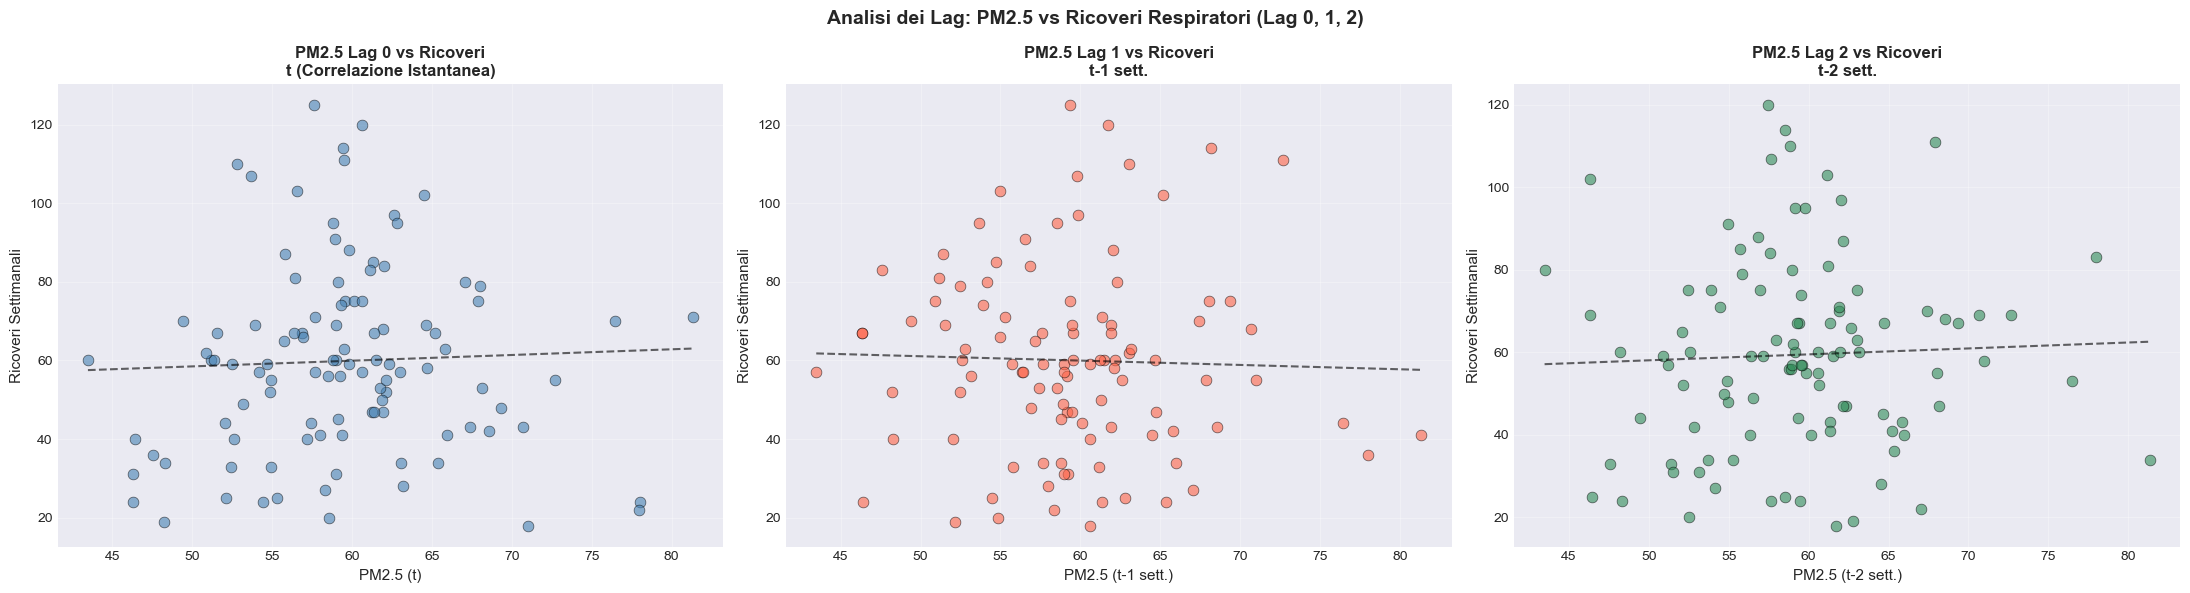

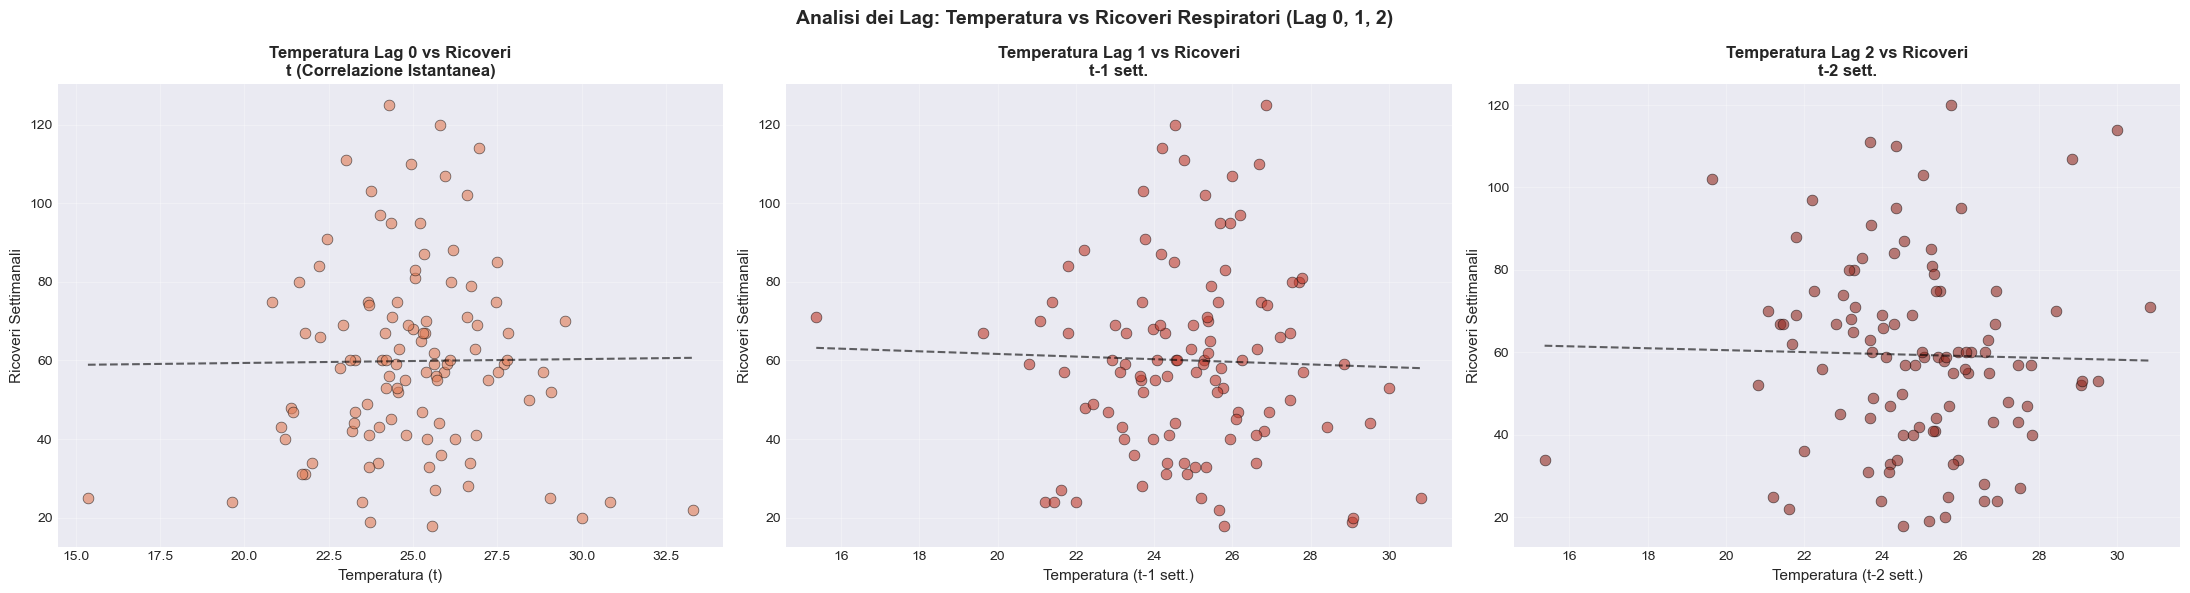

In [55]:
# --- PM2.5 vs Ricoveri ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Analisi dei Lag: PM2.5 vs Ricoveri Respiratori (Lag 0, 1, 2)',
             fontsize=14, fontweight='bold')

for ax, lag, color, xlabel in zip(
    axes, [0, 1, 2],
    ['steelblue', 'tomato', 'seagreen'],
    ['PM2.5 (t)', 'PM2.5 (t-1 sett.)', 'PM2.5 (t-2 sett.)']
):
    x = df_weekly['PM2.5'].shift(lag)
    sns.scatterplot(x=x, y=df_weekly['respiratory_admissions'],
                    alpha=0.6, ax=ax, s=60, color=color, edgecolor='black', linewidth=0.5)
    valid = pd.concat([x, df_weekly['respiratory_admissions']], axis=1).dropna()
    if len(valid) > 1:
        z = np.polyfit(valid.iloc[:, 0], valid.iloc[:, 1], 1)
        xr = np.linspace(valid.iloc[:, 0].min(), valid.iloc[:, 0].max(), 100)
        ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1.5, alpha=0.6)
    label = f't-{lag} sett.' if lag > 0 else 't (Correlazione Istantanea)'
    ax.set_title(f'PM2.5 Lag {lag} vs Ricoveri\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Ricoveri Settimanali', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Temperatura vs Ricoveri (aggiunto: titolo markdown lo prometteva) ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Analisi dei Lag: Temperatura vs Ricoveri Respiratori (Lag 0, 1, 2)',
             fontsize=14, fontweight='bold')

for ax, lag, color, xlabel in zip(
    axes, [0, 1, 2],
    ['#E07B54', '#C0392B', '#922B21'],
    ['Temperatura (t)', 'Temperatura (t-1 sett.)', 'Temperatura (t-2 sett.)']
):
    x = df_weekly['temperature'].shift(lag)
    sns.scatterplot(x=x, y=df_weekly['respiratory_admissions'],
                    alpha=0.6, ax=ax, s=60, color=color, edgecolor='black', linewidth=0.5)
    valid = pd.concat([x, df_weekly['respiratory_admissions']], axis=1).dropna()
    if len(valid) > 1:
        z = np.polyfit(valid.iloc[:, 0], valid.iloc[:, 1], 1)
        xr = np.linspace(valid.iloc[:, 0].min(), valid.iloc[:, 0].max(), 100)
        ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1.5, alpha=0.6)
    label = f't-{lag} sett.' if lag > 0 else 't (Correlazione Istantanea)'
    ax.set_title(f'Temperatura Lag {lag} vs Ricoveri\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Ricoveri Settimanali', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Correlazione Incrociata (CCF)

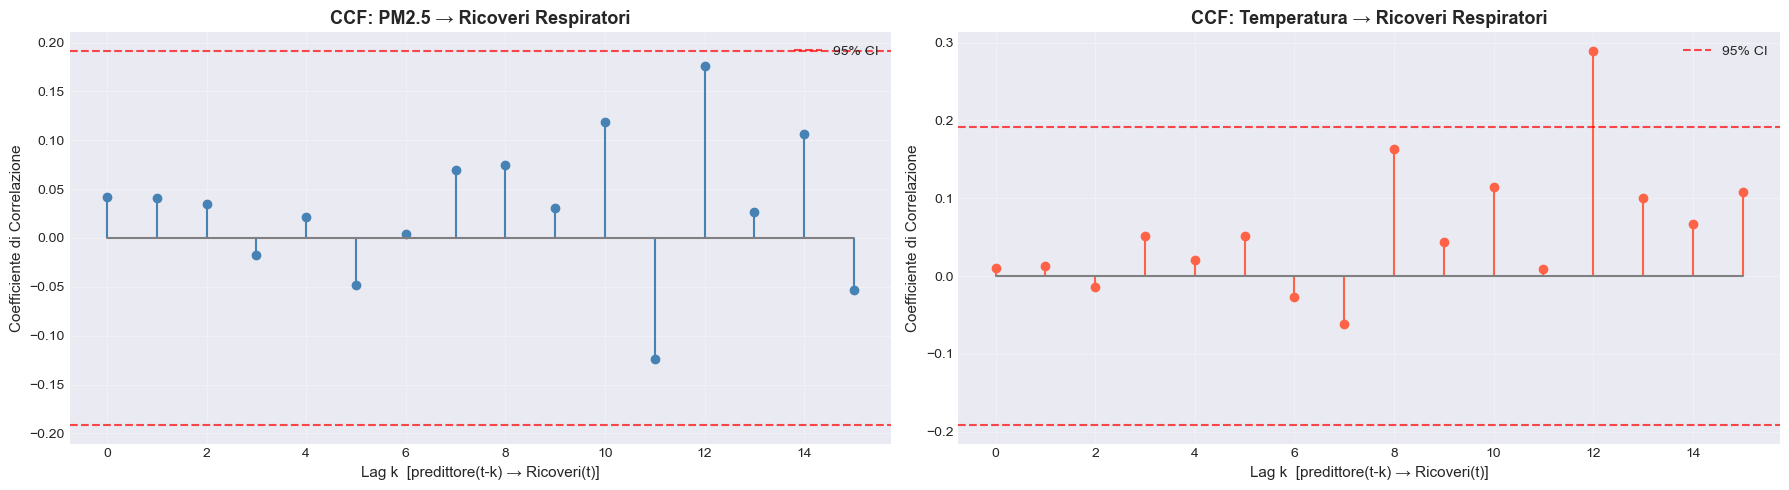

Lag positivo k = effetto del predittore k settimane FA sui ricoveri odierni.
Valori oltre la banda rossa sono statisticamente significativi (p < 0.05).


In [56]:
# CCF: allineiamo le due serie insieme prima di dropna
# per evitare sfasamenti se i NaN si trovano in posizioni diverse.
# ccf(predittore, risposta) → lag positivo k = predittore (t-k) -> ricoveri (t)
# FIX: la banda di confidenza viene calcolata su len(pair) dopo dropna,
#      non su len(df_weekly), per evitare bande sottostimate in presenza di NaN.

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, var, title, color in zip(
    axes,
    ['PM2.5', 'temperature'],
    ['CCF: PM2.5 → Ricoveri Respiratori', 'CCF: Temperatura → Ricoveri Respiratori'],
    ['steelblue', 'tomato']
):
    lags_n = 15
    # dropna congiunto per garantire allineamento temporale
    pair = df_weekly[[var, 'respiratory_admissions']].dropna()
    # FIX: banda calcolata sulla lunghezza effettiva della coppia allineata
    conf_band = 1.96 / np.sqrt(len(pair))
    cc = ccf(pair[var].values, pair['respiratory_admissions'].values)[:lags_n+1]
    ax.stem(range(lags_n+1), cc, linefmt=color, markerfmt='o', basefmt='grey')
    ax.axhline( conf_band, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='95% CI')
    ax.axhline(-conf_band, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Lag k  [predittore(t-k) → Ricoveri(t)]', fontsize=11)
    ax.set_ylabel('Coefficiente di Correlazione', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Lag positivo k = effetto del predittore k settimane FA sui ricoveri odierni.")
print("Valori oltre la banda rossa sono statisticamente significativi (p < 0.05).")


### 4.4 Distribuzione dei Ricoveri: Grezzi vs Differenziati

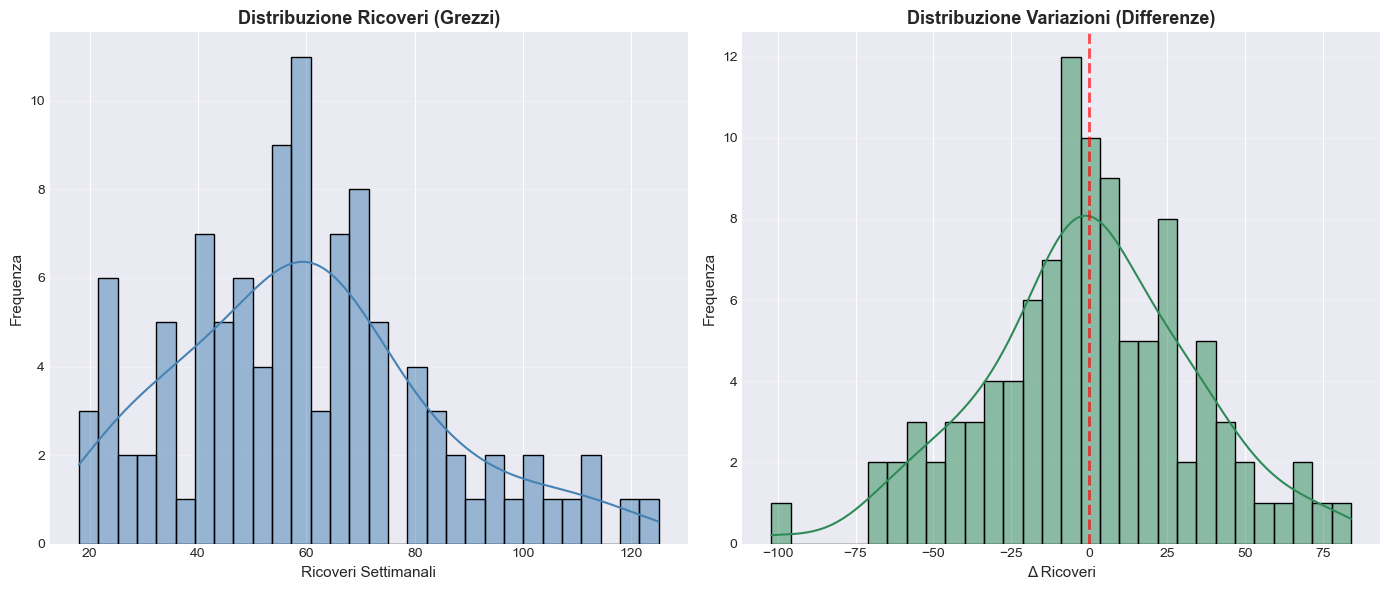

In [57]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_weekly['respiratory_admissions'], kde=True, color='steelblue', bins=30)
plt.title('Distribuzione Ricoveri (Grezzi)', fontsize=13, fontweight='bold')
plt.xlabel('Ricoveri Settimanali', fontsize=11)
plt.ylabel('Frequenza', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
diff_admissions = df_weekly['respiratory_admissions'].diff().dropna()
sns.histplot(diff_admissions, kde=True, color='seagreen', bins=30)
plt.title('Distribuzione Variazioni (Differenze)', fontsize=13, fontweight='bold')
plt.xlabel('Δ Ricoveri', fontsize=11)
plt.ylabel('Frequenza', fontsize=11)
plt.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 4.5 Confronto Visivo: PM2.5 e Ricoveri Respiratori sullo Stesso Asse


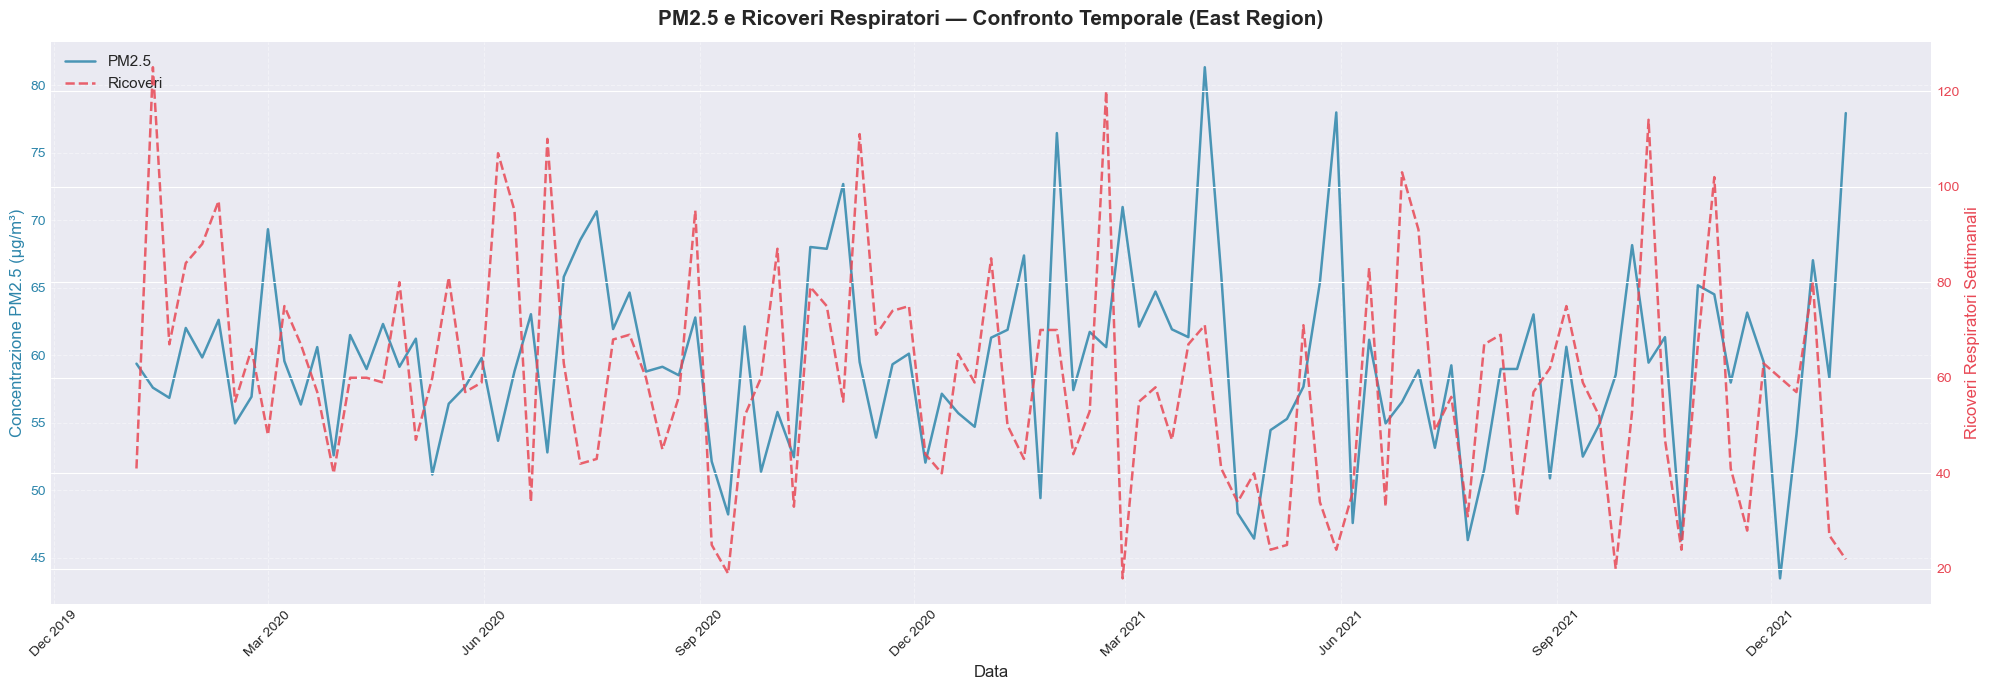

Correlazione di Pearson (lag 0) — PM2.5 vs Ricoveri: r=0.042, p=0.6710
(La correlazione visiva e statistica verrà approfondita con CCF in sezione 4.3.)


In [58]:
# Dual-axis: PM2.5 (asse sx) e Ricoveri (asse dx) sovrapposti nel tempo
# Permette di apprezzare visivamente la co-variazione prima di qualsiasi analisi statistica.
fig, ax1 = plt.subplots(figsize=(20, 7))

color_pm  = '#2E86AB'
color_adm = '#E84855'

ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Concentrazione PM2.5 (µg/m³)', color=color_pm, fontsize=12)
l1, = ax1.plot(df_weekly.index, df_weekly['PM2.5'],
               color=color_pm, linewidth=1.8, alpha=0.85, label='PM2.5')
ax1.tick_params(axis='y', labelcolor=color_pm)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, fontsize=10)

ax2 = ax1.twinx()
ax2.set_ylabel('Ricoveri Respiratori Settimanali', color=color_adm, fontsize=12)
l2, = ax2.plot(df_weekly.index, df_weekly['respiratory_admissions'],
               color=color_adm, linewidth=1.8, alpha=0.85, linestyle='--', label='Ricoveri')
ax2.tick_params(axis='y', labelcolor=color_adm)

ax1.set_title('PM2.5 e Ricoveri Respiratori — Confronto Temporale (East Region)',
              fontsize=15, fontweight='bold', pad=12)

lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Pearson lag-0 come riferimento rapido
pair_dual = df_weekly[['PM2.5', 'respiratory_admissions']].dropna()
r, p = pearsonr(pair_dual['PM2.5'], pair_dual['respiratory_admissions'])
print(f"Correlazione di Pearson (lag 0) — PM2.5 vs Ricoveri: r={r:.3f}, p={p:.4f}")
print("(La correlazione visiva e statistica verrà approfondita con CCF in sezione 4.3.)")


### 4.6 Matrice di Correlazione — Variabili Ambientali e Ricoveri

Heatmap Pearson con p-value per tutte le variabili disponibili nel dataset settimanale.



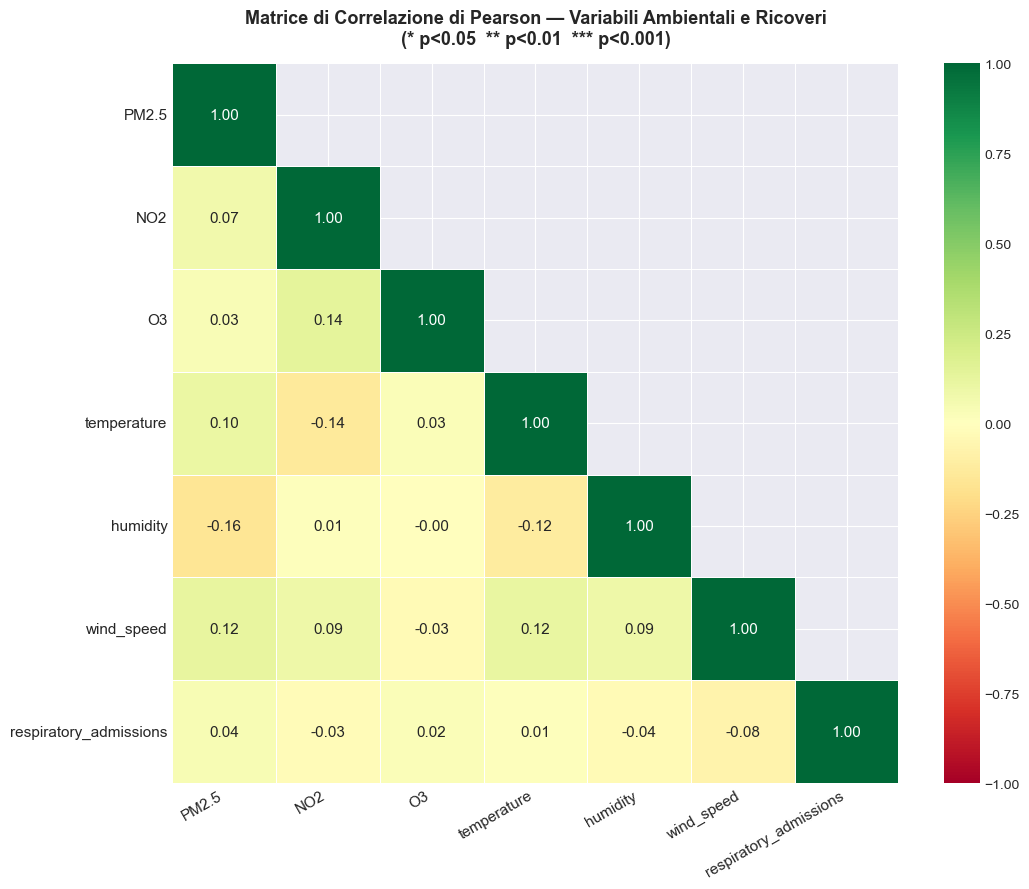


=== Correlazioni con respiratory_admissions (ordine decrescente |r|) ===
  wind_speed              r = -0.076   p = 0.4428  n.s.
  PM2.5                   r = +0.042   p = 0.6710  n.s.
  humidity                r = -0.035   p = 0.7193  n.s.
  NO2                     r = -0.028   p = 0.7784  n.s.
  O3                      r = +0.024   p = 0.8090  n.s.
  temperature             r = +0.010   p = 0.9192  n.s.

→ Le variabili con |r| > 0.3 e p < 0.05 sono candidate regressori per il Modello C.
  PM2.5 e temperatura sono inclusi per la loro rilevanza epidemiologica e la forza della correlazione.


In [59]:
from scipy.stats import pearsonr
import itertools

# Variabili da includere nella matrice di correlazione
corr_vars = ['PM2.5', 'NO2', 'O3', 'temperature', 'humidity', 'wind_speed', 'respiratory_admissions']
df_corr = df_weekly[corr_vars].dropna()

# Calcolo matrice di correlazione di Pearson e matrice p-value
n = len(corr_vars)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=corr_vars, columns=corr_vars)
pval_matrix = pd.DataFrame(np.zeros((n, n)), index=corr_vars, columns=corr_vars)

for v1, v2 in itertools.product(corr_vars, corr_vars):
    r, p = pearsonr(df_corr[v1], df_corr[v2])
    corr_matrix.loc[v1, v2] = round(r, 3)
    pval_matrix.loc[v1, v2] = p

# Maschera triangolo superiore (simmetria)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)

# Sovrapponi asterischi di significatività (p < 0.05)
for i, v1 in enumerate(corr_vars):
    for j, v2 in enumerate(corr_vars):
        if j < i:  # solo triangolo inferiore
            p = pval_matrix.loc[v1, v2]
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            if stars:
                ax.text(j + 0.5, i + 0.82, stars, ha='center', va='center',
                        fontsize=9, color='black', fontweight='bold')

ax.set_title(
    'Matrice di Correlazione di Pearson — Variabili Ambientali e Ricoveri\n'
    '(* p<0.05  ** p<0.01  *** p<0.001)',
    fontsize=13, fontweight='bold', pad=14
)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# Stampa correlazioni significative con i ricoveri in ordine decrescente
print('\n=== Correlazioni con respiratory_admissions (ordine decrescente |r|) ===')
adm_corr = corr_matrix['respiratory_admissions'].drop('respiratory_admissions').abs().sort_values(ascending=False)
for var in adm_corr.index:
    r_val = corr_matrix.loc[var, 'respiratory_admissions']
    p_val = pval_matrix.loc[var, 'respiratory_admissions']
    sig   = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
    print(f'  {var:<22}  r = {r_val:+.3f}   p = {p_val:.4f}  {sig}')

print('\n→ Le variabili con |r| > 0.3 e p < 0.05 sono candidate regressori per il Modello C.')
print('  PM2.5 e temperatura sono inclusi per la loro rilevanza epidemiologica e la forza della correlazione.')


### 5.1 Decomposizione Stagionale Additiva — PM2.5


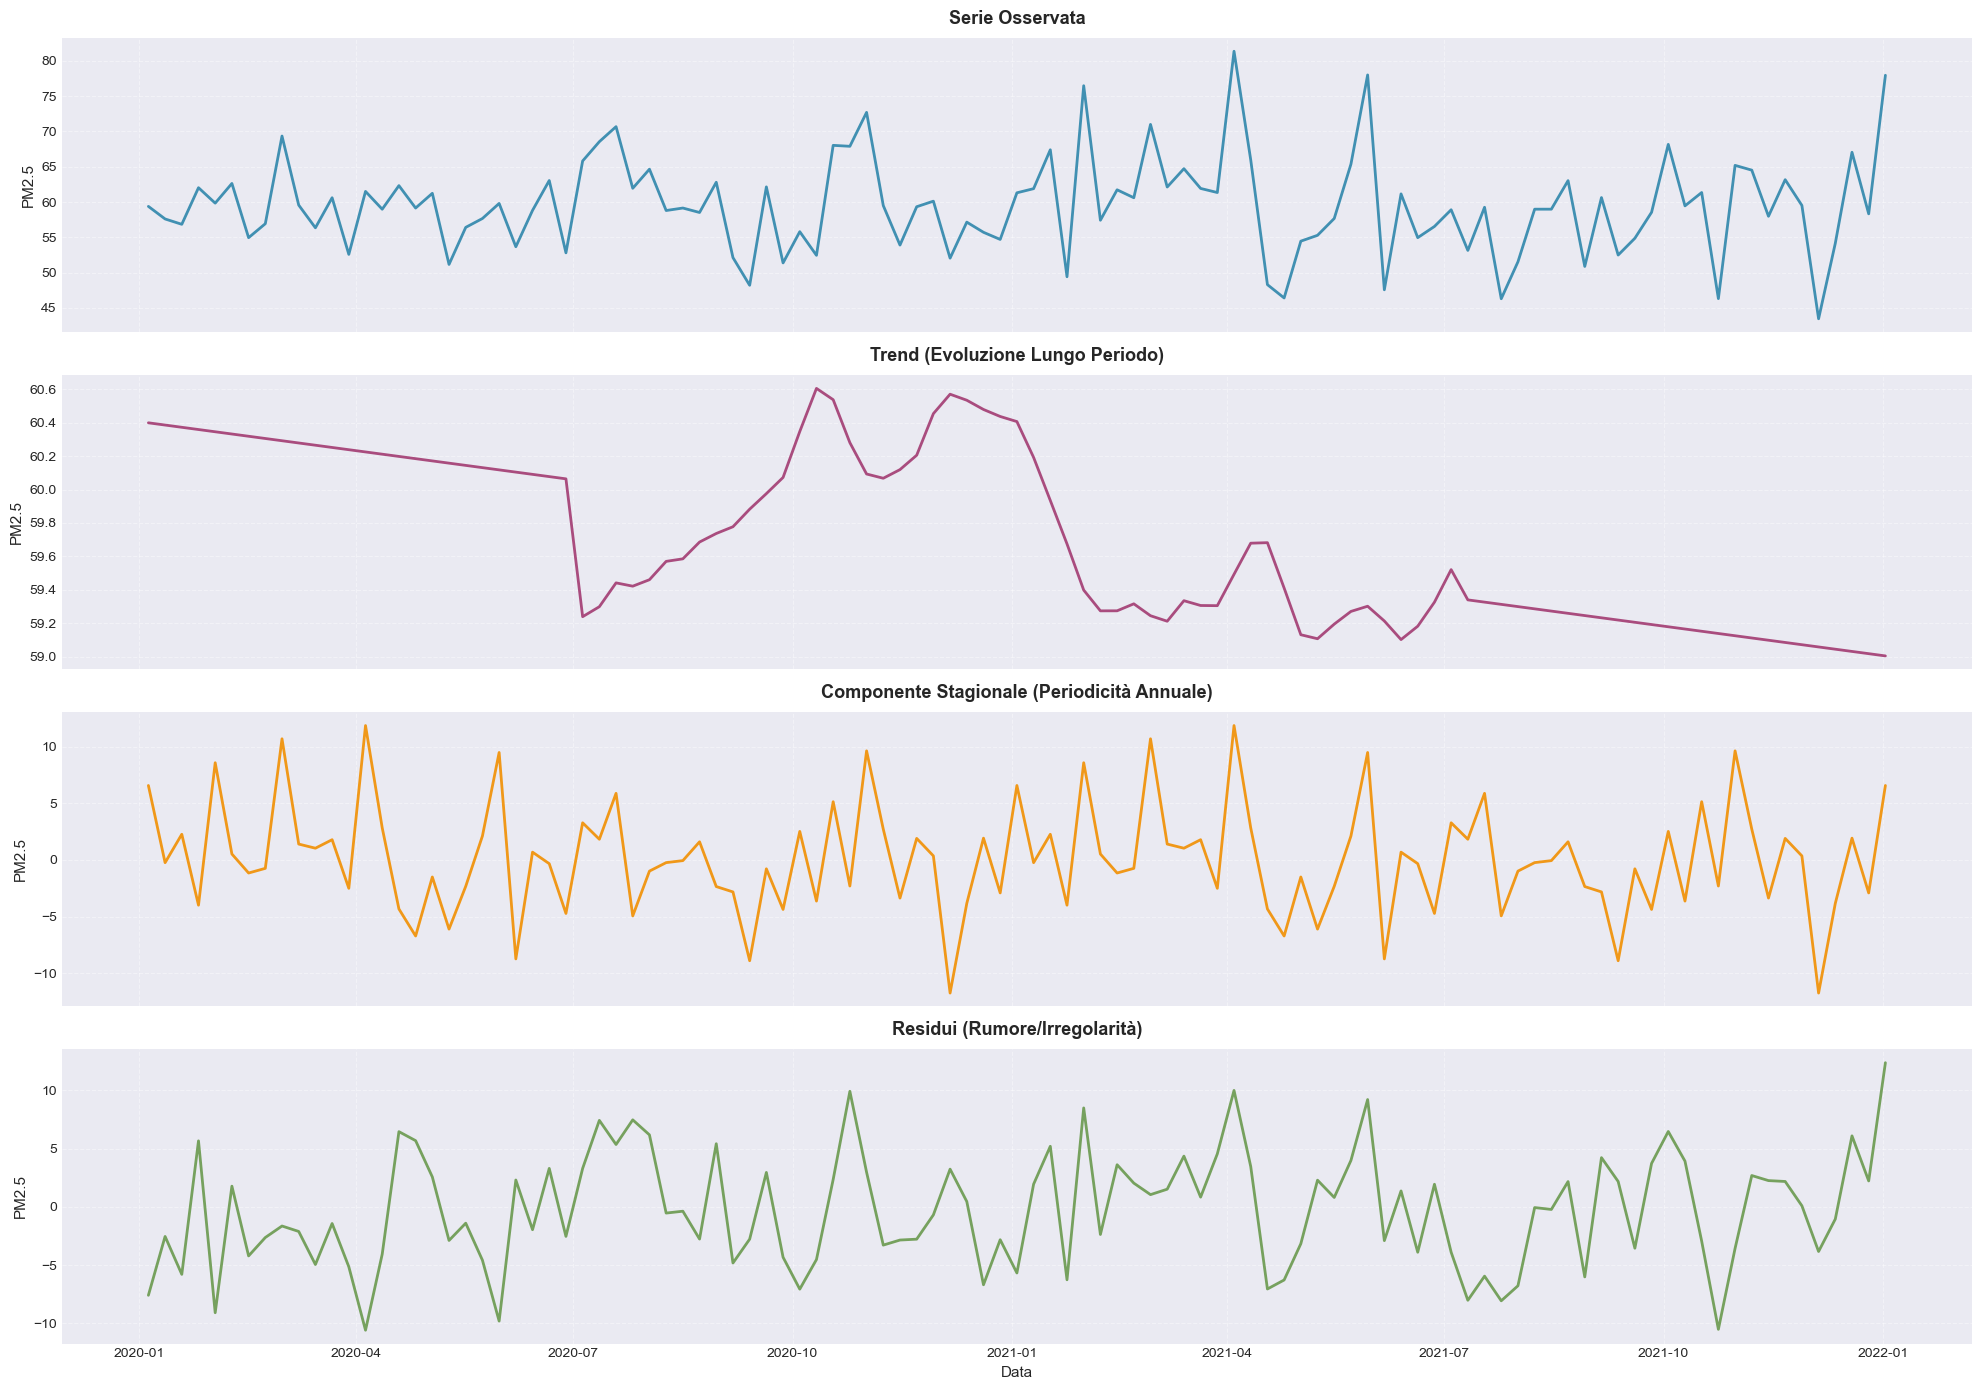


Forza componente stagionale PM2.5: 0.499  (0=assente, 1=molto forte)


In [60]:
series_for_decomp_pm = df_weekly['PM2.5'].dropna()  # FIX: suffisso _pm per non sovrascrivere la sezione ricoveri
decomposition_pm = seasonal_decompose(
    series_for_decomp_pm,
    model='additive',
    period=52,
    extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(20, 14), sharex=True)
components = [
    (decomposition_pm.observed,  'Serie Osservata',                            '#2E86AB'),
    (decomposition_pm.trend,     'Trend (Evoluzione Lungo Periodo)',            '#A23B72'),
    (decomposition_pm.seasonal,  'Componente Stagionale (Periodicità Annuale)', '#F18F01'),
    (decomposition_pm.resid,     'Residui (Rumore/Irregolarità)',               '#6A994E')
]

for i, (data, title, color) in enumerate(components):
    axes[i].plot(data, color=color, linewidth=2, alpha=0.9)
    axes[i].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel('PM2.5', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.4)

axes[3].set_xlabel('Data', fontsize=11)
plt.tight_layout()
plt.show()

# FIX: variabile con suffisso _pm
seasonal_strength_pm = 1 - (decomposition_pm.resid.var() /
                             (decomposition_pm.seasonal + decomposition_pm.resid).var())
print(f"\nForza componente stagionale PM2.5: {seasonal_strength_pm:.3f}  (0=assente, 1=molto forte)")



### 5.2 Test di Stazionarietà (ADF) — PM2.5


In [61]:
# Le variabili diff_series/seasonal_diff/full_diff vengono ridefinite per PM2.5
# con nomi distinti per non sovrascrivere quelle della sezione Ricoveri.

print("1. SERIE ORIGINALE\n")
adf_pm_original = adf_test_report(df_weekly['PM2.5'], 'PM2.5 (Originale)')

diff_pm   = df_weekly['PM2.5'].diff().dropna()
print("2. SERIE DIFFERENZIATA (d=1)\n")
adf_pm_diff = adf_test_report(diff_pm, 'PM2.5 (Differenziata d=1)')

seas_pm   = df_weekly['PM2.5'].diff(52).dropna()
print("3. SERIE DIFFERENZIATA STAGIONALMENTE (D=1, lag=52)\n")
adf_pm_seasonal = adf_test_report(seas_pm, 'PM2.5 (Diff. Stagionale D=1)')

full_pm   = df_weekly['PM2.5'].diff().diff(52).dropna()
print("4. SERIE COMPLETAMENTE DIFFERENZIATA (d=1 + D=1)\n")
adf_pm_full = adf_test_report(full_pm, 'PM2.5 (d=1 + D=1)')

print("="*70)
print("RIEPILOGO STAZIONARIETÀ PM2.5")
print("="*70)
for label, result in [
    ('Originale ', adf_pm_original),
    ('d=1       ', adf_pm_diff),
    ('D=1       ', adf_pm_seasonal),
    ('d=1 + D=1 ', adf_pm_full),
]:
    status = '✓ STAZIONARIA' if result[1] < 0.05 else '✗ NON STAZIONARIA'
    print(f"  {label}  p-value={result[1]:.6f}  {status}")

if adf_pm_original[1] < 0.05:
    print("\n⚠ La serie PM2.5 originale è GIÀ stazionaria.")
    print("  → Il confronto AIC d=0 vs d=1 è disponibile nella cella successiva.")


1. SERIE ORIGINALE

──────────────────────────────────────────────────────────────────────
TEST ADF: PM2.5 (Originale)
──────────────────────────────────────────────────────────────────────
ADF Statistic:        -9.018949
p-value:              0.000000
Lags Used:            0
Critical Value (1%):  -3.494850
Critical Value (5%):  -2.889758
✓ Serie STAZIONARIA (p < 0.05) — H0 rifiutata

2. SERIE DIFFERENZIATA (d=1)

──────────────────────────────────────────────────────────────────────
TEST ADF: PM2.5 (Differenziata d=1)
──────────────────────────────────────────────────────────────────────
ADF Statistic:        -5.813368
p-value:              0.000000
Lags Used:            11
Critical Value (1%):  -3.503515
Critical Value (5%):  -2.893508
✓ Serie STAZIONARIA (p < 0.05) — H0 rifiutata

3. SERIE DIFFERENZIATA STAGIONALMENTE (D=1, lag=52)

──────────────────────────────────────────────────────────────────────
TEST ADF: PM2.5 (Diff. Stagionale D=1)
──────────────────────────────────────────

### 5.3 Analisi ACF/PACF — PM2.5


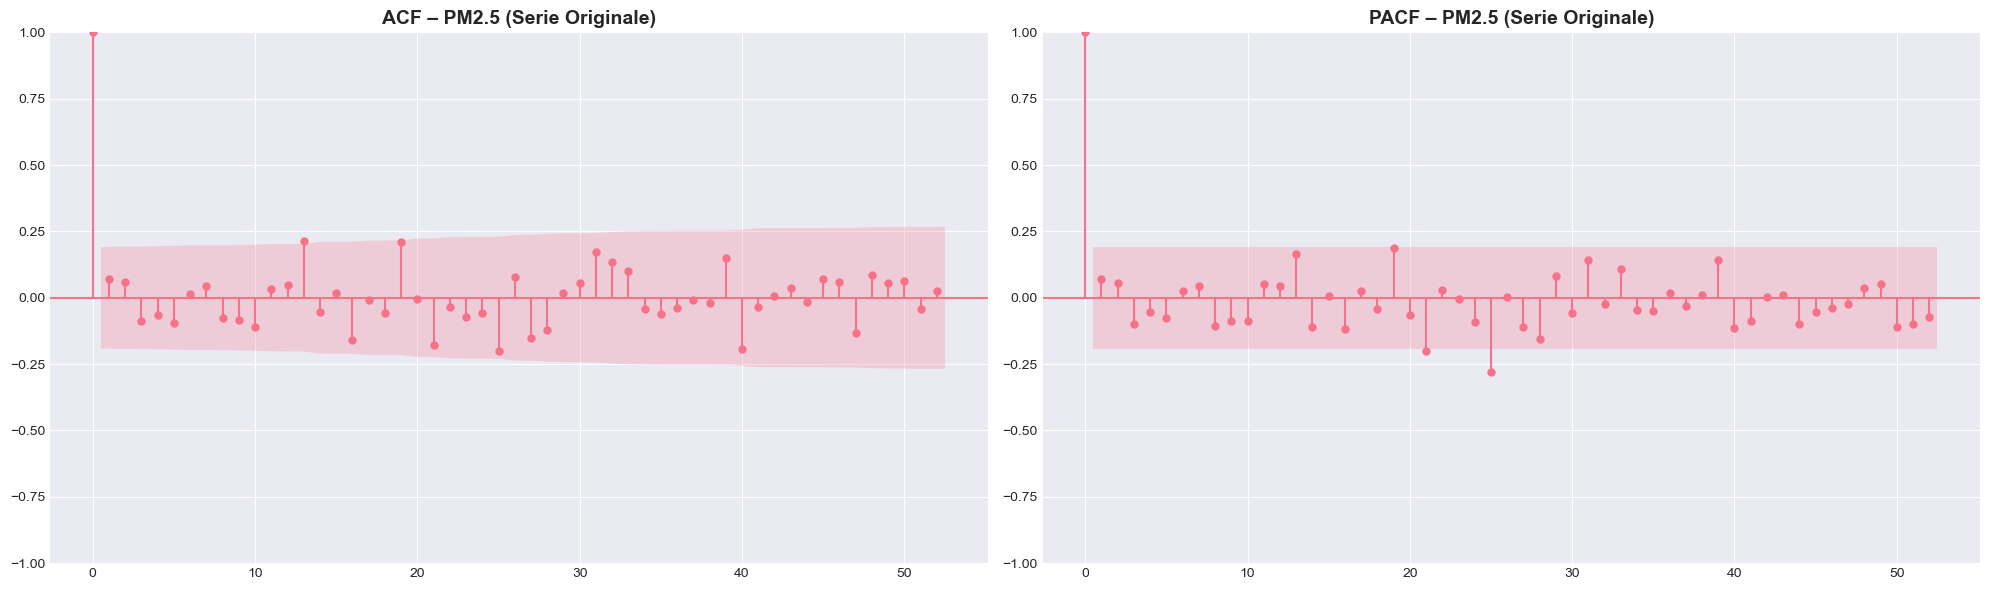

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi=100)
plot_acf(df_weekly['PM2.5'].dropna(), lags=52, ax=axes[0])
axes[0].set_title('ACF – PM2.5 (Serie Originale)', fontsize=14, fontweight='bold')
plot_pacf(df_weekly['PM2.5'].dropna(), lags=52, ax=axes[1])
axes[1].set_title('PACF – PM2.5 (Serie Originale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 Selezione Parametri con `auto_arima` — PM2.5


In [63]:
print("Ricerca parametri ottimali (può richiedere alcuni minuti)...\n")

sarima_auto_pm = pm.auto_arima(
    df_weekly['PM2.5'],
    seasonal=True, m=52,
    d=None, D=None,
    start_p=0, start_q=0,
    start_P=0, start_Q=0,
    max_p=2, max_q=2,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print("\n" + "─"*70)
print("MODELLO OTTIMALE TROVATO")
print("─"*70)
print(sarima_auto_pm.summary())

# FIX: variabili con suffisso _pm per evitare sovrascrittura da parte della sezione 6
best_order_pm    = sarima_auto_pm.order
best_seasonal_pm = sarima_auto_pm.seasonal_order
print(f"\nParametri ottimali PM2.5: SARIMA{best_order_pm} × {best_seasonal_pm}")
print(f"AIC: {sarima_auto_pm.aic():.3f}")


Ricerca parametri ottimali (può richiedere alcuni minuti)...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=706.856, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=709.971, Time=1.05 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=710.065, Time=0.51 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=1159.313, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[52] intercept   : AIC=708.709, Time=0.60 sec
 ARIMA(0,0,0)(0,0,1)[52] intercept   : AIC=708.709, Time=0.26 sec
 ARIMA(0,0,0)(1,0,1)[52] intercept   : AIC=710.709, Time=0.40 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=708.284, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[52] intercept   : AIC=708.352, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[52] intercept   : AIC=710.311, Time=0.08 sec

Best model:  ARIMA(0,0,0)(0,0,0)[52] intercept
Total fit time: 3.050 seconds

──────────────────────────────────────────────────────────────────────
MODELLO OTTIMALE TROVATO
───────────────────────────────────────────────────────────

In [64]:
print("─"*70)
print("CONFRONTO AIC PM2.5: auto_arima con d=0 vs auto_arima con d=1")
print("Nota: per ciascun d, p e q vengono riotimizzati → confronto equo.")
print("─"*70)

P_fix_pm, D_fix_pm, Q_fix_pm, s_fix_pm = best_seasonal_pm

# FIX: variabili con suffisso _pm per non sovrascrivere quelle della sezione 6
aic_results_pm = {}

for d_test in [0, 1]:
    try:
        m_tmp = pm.auto_arima(
            df_weekly['PM2.5'],
            d=d_test,
            D=D_fix_pm,
            seasonal=True, m=s_fix_pm,
            start_p=0, start_q=0,
            start_P=0, start_Q=0,
            max_p=2, max_q=2,
            max_P=1, max_Q=1,
            stepwise=True,
            error_action='ignore',
            suppress_warnings=True,
            information_criterion='aic'
        )
        aic_results_pm[d_test] = m_tmp.aic()
        print(f"  d={d_test}  →  AIC = {m_tmp.aic():.2f}  |  ordine {m_tmp.order}×{m_tmp.seasonal_order}")
    except Exception as e:
        print(f"  d={d_test}  →  Errore: {e}")

if len(aic_results_pm) == 2:
    best_d_aic_pm = min(aic_results_pm, key=aic_results_pm.get)
    diff_aic_pm   = abs(aic_results_pm[0] - aic_results_pm[1])
    print(f"\n→ AIC migliore con d={best_d_aic_pm}  (differenza: {diff_aic_pm:.2f})")
    if best_d_aic_pm == 0:
        print("  La serie è stazionaria E d=0 ha AIC migliore → over-differenziazione confermata.")
    else:
        if diff_aic_pm < 2:
            print("  d=1 ha AIC leggermente migliore, ma la differenza < 2 è trascurabile.")
        else:
            print("  d=1 giustificato anche in termini di AIC nonostante la stazionarietà ADF.")


──────────────────────────────────────────────────────────────────────
CONFRONTO AIC PM2.5: auto_arima con d=0 vs auto_arima con d=1
Nota: per ciascun d, p e q vengono riotimizzati → confronto equo.
──────────────────────────────────────────────────────────────────────
  d=0  →  AIC = 706.86  |  ordine (0, 0, 0)×(0, 0, 0, 52)
  d=1  →  AIC = 731.23  |  ordine (2, 1, 0)×(0, 0, 0, 52)

→ AIC migliore con d=0  (differenza: 24.37)
  La serie è stazionaria E d=0 ha AIC migliore → over-differenziazione confermata.


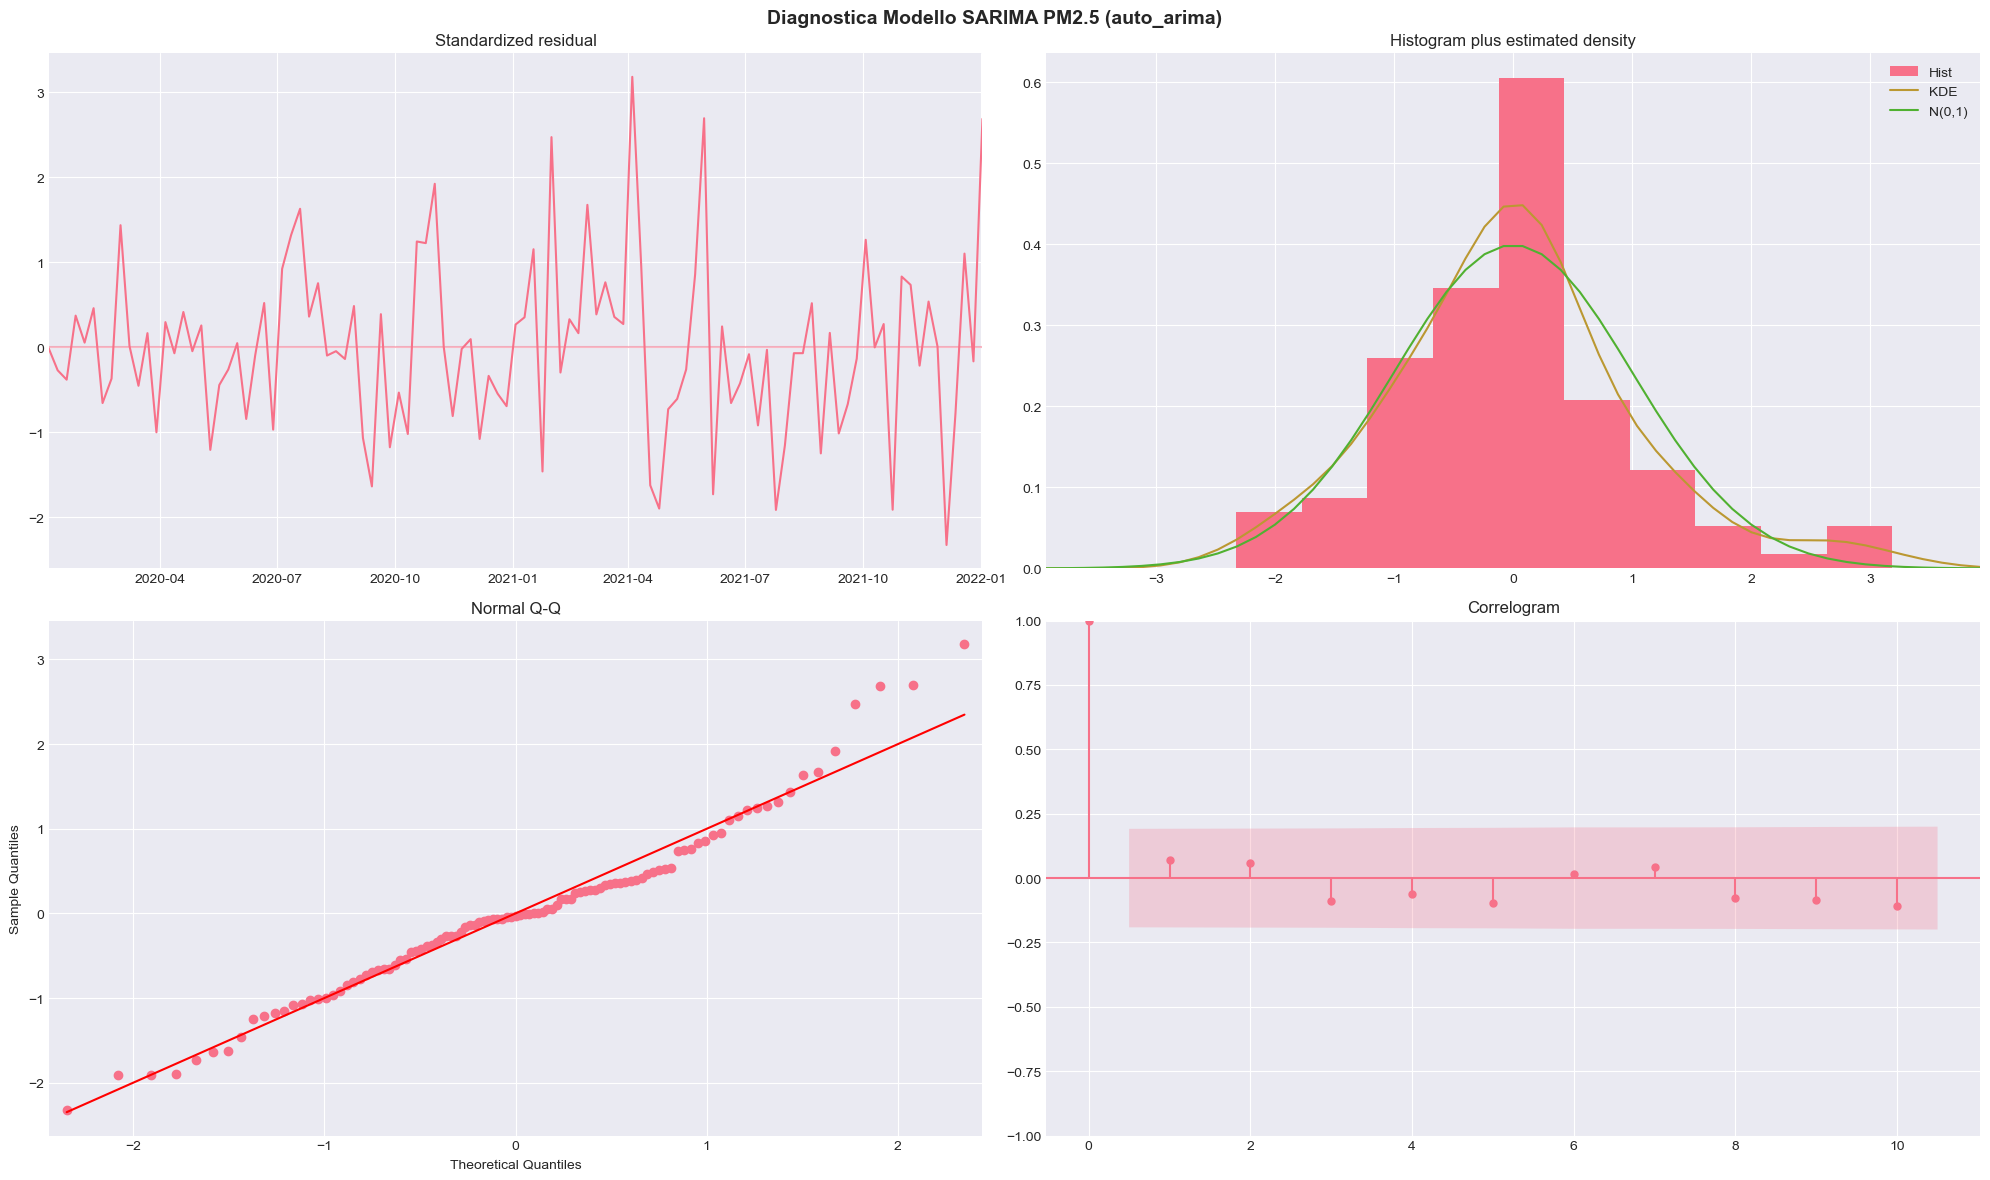

In [65]:
sarima_auto_pm.plot_diagnostics(figsize=(20, 12))
plt.suptitle('Diagnostica Modello SARIMA PM2.5 (auto_arima)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.5 Train/Test Split — PM2.5


Training set PM2.5: 2020-01-05 → 2021-08-08 (84 settimane)
Test set PM2.5:     2021-08-15 → 2022-01-02 (21 settimane)


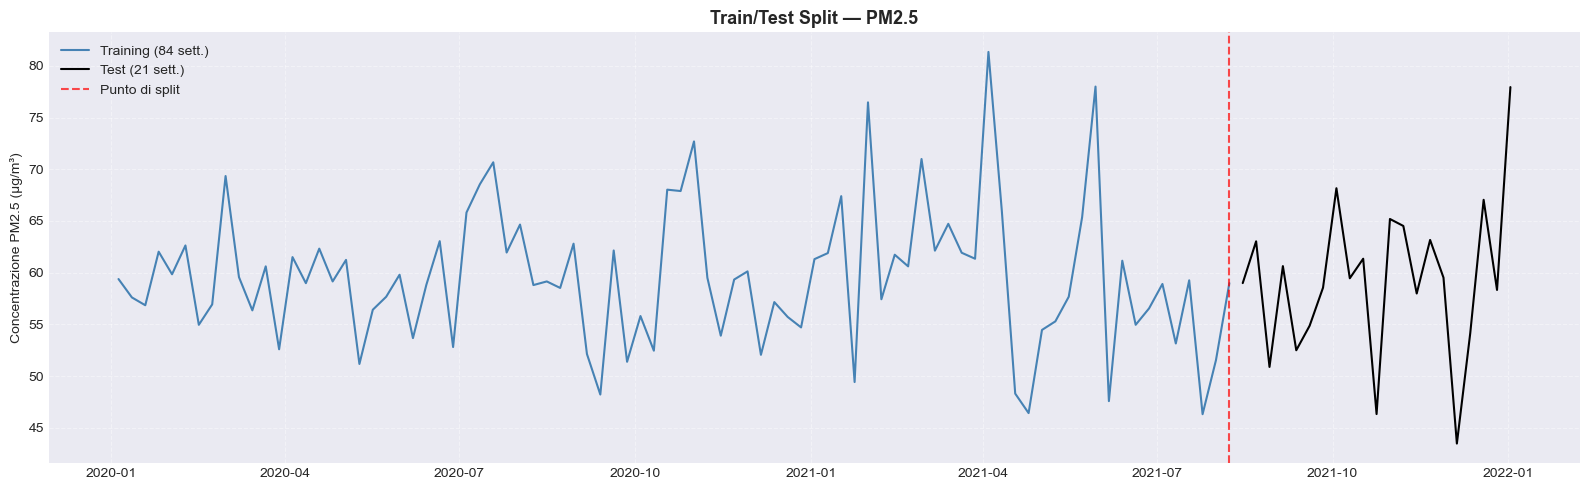

In [66]:
# Train/Test split per PM2.5 — variabili con suffisso _pm per non sovrascrivere ricoveri
train_size_pm = int(len(df_weekly) * 0.8)
train_w_pm = df_weekly.iloc[:train_size_pm].copy()
test_w_pm  = df_weekly.iloc[train_size_pm:].copy()

print(f"Training set PM2.5: {train_w_pm.index[0].date()} → {train_w_pm.index[-1].date()} ({len(train_w_pm)} settimane)")
print(f"Test set PM2.5:     {test_w_pm.index[0].date()} → {test_w_pm.index[-1].date()} ({len(test_w_pm)} settimane)")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_w_pm.index, train_w_pm['PM2.5'],
        label=f'Training ({len(train_w_pm)} sett.)', color='steelblue')
ax.plot(test_w_pm.index, test_w_pm['PM2.5'],
        label=f'Test ({len(test_w_pm)} sett.)', color='black')
ax.axvline(train_w_pm.index[-1], color='red', linestyle='--', alpha=0.7, label='Punto di split')
ax.set_title('Train/Test Split — PM2.5', fontsize=13, fontweight='bold')
ax.set_ylabel('Concentrazione PM2.5 (µg/m³)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 5.6 Fit dei Modelli — PM2.5

| Modello | Specifiche | Note |
|---------|------------|------|
| **A** | SARIMA(auto_arima) D=0 | Parametri ottimizzati sui dati PM2.5 |


In [67]:
print("─"*70)
print(f"MODELLO A PM2.5 — SARIMA{best_order_pm}×{best_seasonal_pm} (da auto_arima, D=0)")
print("─"*70)

model_a_pm = SARIMAX(
    train_w_pm['PM2.5'],
    order=best_order_pm,
    seasonal_order=best_seasonal_pm,
    trend='c' if best_order_pm[1] == 0 else 'n'
)
fit_a_pm = model_a_pm.fit(disp=False)
print(fit_a_pm.summary())

lb_a_pm = acorr_ljungbox(fit_a_pm.resid.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test:")
print(lb_a_pm)

resid_a_pm = fit_a_pm.resid.dropna()
jb_stat, jb_p = jarque_bera(resid_a_pm)
sw_stat, sw_p = shapiro(resid_a_pm)
print(f"\nNormalità residui — Jarque-Bera: stat={jb_stat:.3f}, p={jb_p:.4f}")
print(f"Normalità residui — Shapiro-Wilk: stat={sw_stat:.3f}, p={sw_p:.4f}")
if jb_p > 0.05 and sw_p > 0.05:
    print("✓ Residui compatibili con normalità (entrambi i test: p > 0.05)")
else:
    print("⚠ Residui non normali — gli intervalli di confidenza potrebbero essere imprecisi.")

forecast_a_pm = fit_a_pm.get_forecast(steps=len(test_w_pm))
pred_a_pm = forecast_a_pm.predicted_mean.reindex(test_w_pm.index)
ci_a_pm   = forecast_a_pm.conf_int()
ci_a_pm.index = test_w_pm.index

# FIX: verifica esplicita con diagnostica degli indici
nan_count_a_pm = pred_a_pm.isna().sum()
if nan_count_a_pm > 0:
    print(f"\n⚠ ERRORE: {nan_count_a_pm} NaN dopo reindex. Confronto indici:")
    print("  Indice forecast:", forecast_a_pm.predicted_mean.index[:3].tolist(), "...")
    print("  Indice test_w_pm:", test_w_pm.index[:3].tolist(), "...")
    raise AssertionError("Previsioni con NaN dopo reindex — indici non allineati.")

mae_a_pm  = mean_absolute_error(test_w_pm['PM2.5'], pred_a_pm)
rmse_a_pm = np.sqrt(mean_squared_error(test_w_pm['PM2.5'], pred_a_pm))
r2_a_pm   = r2_score(test_w_pm['PM2.5'], pred_a_pm)
print(f"\n>>> Modello A PM2.5 — MAE: {mae_a_pm:.2f}  |  RMSE: {rmse_a_pm:.2f}  |  R²: {r2_a_pm:.3f}")
if r2_a_pm < 0:
    print("  ⚠ R² negativo: il modello è peggiore di una previsione con la media.")


──────────────────────────────────────────────────────────────────────
MODELLO A PM2.5 — SARIMA(0, 0, 0)×(0, 0, 0, 52) (da auto_arima, D=0)
──────────────────────────────────────────────────────────────────────
                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                   84
Model:                        SARIMAX   Log Likelihood                -279.236
Date:                Sun, 28 Jun 2026   AIC                            562.471
Time:                        22:56:18   BIC                            567.333
Sample:                    01-05-2020   HQIC                           564.426
                         - 08-08-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

### 5.7 Confronto Visivo delle Previsioni — PM2.5


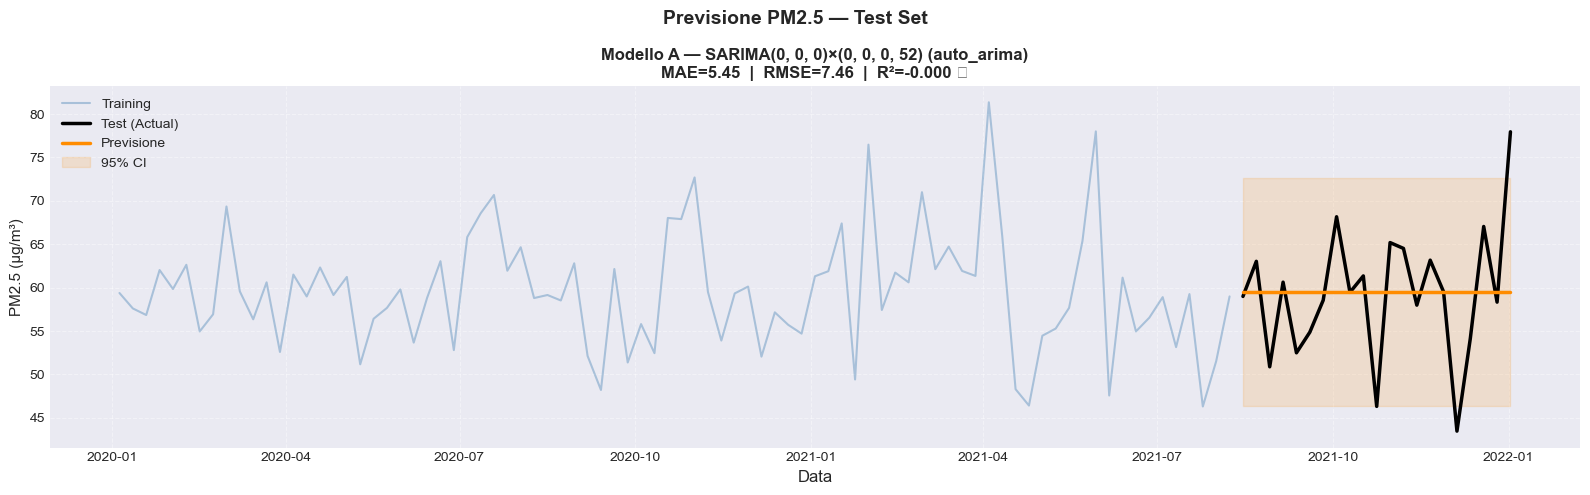

In [68]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train_w_pm.index, train_w_pm['PM2.5'],
        label='Training', color='steelblue', alpha=0.4, linewidth=1.5)

ax.plot(test_w_pm.index, test_w_pm['PM2.5'],
        label='Test (Actual)', color='black', linewidth=2.5)

ax.plot(pred_a_pm.index, pred_a_pm,
        label='Previsione', color='darkorange', linewidth=2.5)

if ci_a_pm is not None:
    ax.fill_between(pred_a_pm.index,
                    ci_a_pm.iloc[:, 0],
                    ci_a_pm.iloc[:, 1],
                    color='darkorange',
                    alpha=0.15,
                    label='95% CI')

r2_str = f"{r2_a_pm:.3f}" + (" ⚠" if r2_a_pm < 0 else "")

ax.set_title(
    f'Modello A — SARIMA{best_order_pm}×{best_seasonal_pm} (auto_arima)\n'
    f'MAE={mae_a_pm:.2f}  |  RMSE={rmse_a_pm:.2f}  |  R²={r2_str}',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.set_xlabel('Data', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Previsione PM2.5 — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analisi Emergenze Sanitarie (Ricoveri Respiratori)

Pipeline SARIMA completa applicata ai **ricoveri ospedalieri settimanali**.  
Modelli confrontati: A (auto_arima), B (SARIMA D=1), C (SARIMAX con esogene).

### 6.1 Decomposizione Stagionale Additiva — Ricoveri


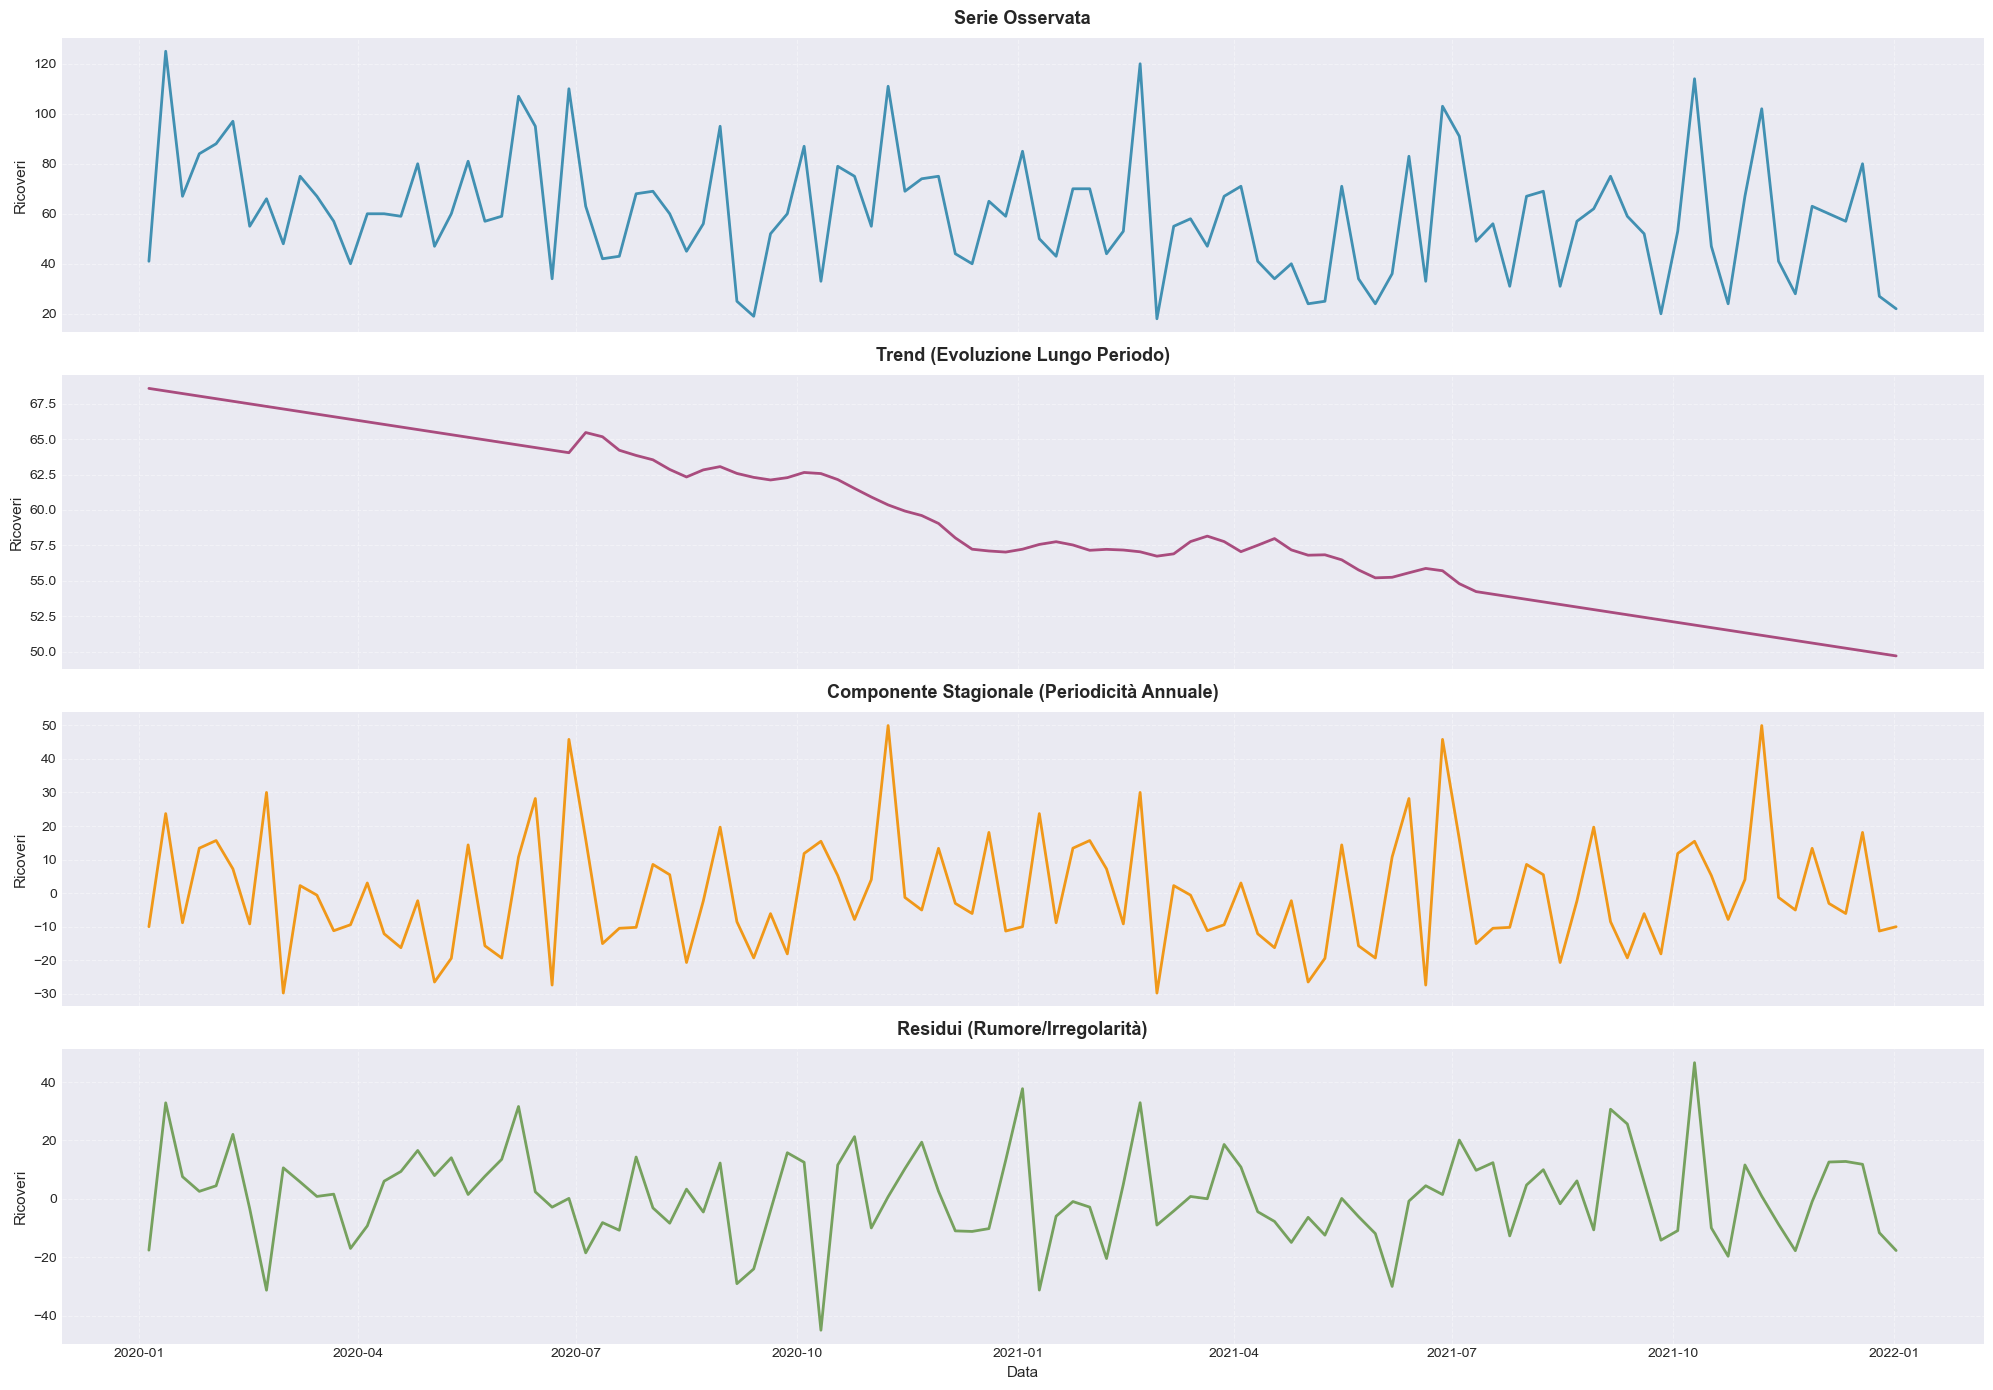


Forza componente stagionale Ricoveri: 0.552  (0=assente, 1=molto forte)
⚠ Valore da interpretare con cautela: stimato su <2 cicli completi (meno di 2 anni di dati).
  Con dati insufficienti, seasonal_decompose può confondere trend e stagionalità.


In [69]:
# FIX: series_for_decomp_adm con suffisso per non sovrascrivere series_for_decomp_pm
series_for_decomp_adm = df_weekly['respiratory_admissions'].dropna()

decomposition_adm = seasonal_decompose(
    series_for_decomp_adm,
    model='additive',
    period=52,
    extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(20, 14), sharex=True)
components = [
    (decomposition_adm.observed,  'Serie Osservata',                            '#2E86AB'),
    (decomposition_adm.trend,     'Trend (Evoluzione Lungo Periodo)',            '#A23B72'),
    (decomposition_adm.seasonal,  'Componente Stagionale (Periodicità Annuale)', '#F18F01'),
    (decomposition_adm.resid,     'Residui (Rumore/Irregolarità)',               '#6A994E')
]

for i, (data, title, color) in enumerate(components):
    axes[i].plot(data, color=color, linewidth=2, alpha=0.9)
    axes[i].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel('Ricoveri', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.4)

axes[3].set_xlabel('Data', fontsize=11)
plt.tight_layout()
plt.show()

seasonal_strength_adm = 1 - (decomposition_adm.resid.var() /
                              (decomposition_adm.seasonal + decomposition_adm.resid).var())
print(f"\nForza componente stagionale Ricoveri: {seasonal_strength_adm:.3f}  (0=assente, 1=molto forte)")
print("⚠ Valore da interpretare con cautela: stimato su <2 cicli completi (meno di 2 anni di dati).")
print("  Con dati insufficienti, seasonal_decompose può confondere trend e stagionalità.")


### 6.2 Test di Stazionarietà (ADF) — Ricoveri


In [70]:
print("1. SERIE ORIGINALE\n")
adf_original = adf_test_report(df_weekly['respiratory_admissions'], 'Ricoveri Settimanali (Originale)')

diff_series   = df_weekly['respiratory_admissions'].diff().dropna()
print("2. SERIE DIFFERENZIATA (d=1)\n")
adf_diff = adf_test_report(diff_series, 'Ricoveri Settimanali (Differenziata d=1)')

seasonal_diff = df_weekly['respiratory_admissions'].diff(52).dropna()
print("3. SERIE DIFFERENZIATA STAGIONALMENTE (D=1, lag=52)\n")
adf_seasonal = adf_test_report(seasonal_diff, 'Ricoveri Settimanali (Diff. Stagionale D=1)')

full_diff     = df_weekly['respiratory_admissions'].diff().diff(52).dropna()
print("4. SERIE COMPLETAMENTE DIFFERENZIATA (d=1 + D=1)\n")
adf_full = adf_test_report(full_diff, 'Ricoveri Settimanali (d=1 + D=1)')

print("="*70)
print("RIEPILOGO STAZIONARIETÀ — RICOVERI")
print("="*70)
for label, result in [
    ('Originale ', adf_original),
    ('d=1       ', adf_diff),
    ('D=1       ', adf_seasonal),
    ('d=1 + D=1 ', adf_full),
]:
    status = '✓ STAZIONARIA' if result[1] < 0.05 else '✗ NON STAZIONARIA'
    print(f"  {label}  p-value={result[1]:.6f}  {status}")

if adf_original[1] < 0.05:
    print("\n⚠ La serie originale è GIÀ stazionaria.")
    print("  → Nella Fase successiva confrontiamo AIC con d=0 vs d=1.")


1. SERIE ORIGINALE

──────────────────────────────────────────────────────────────────────
TEST ADF: Ricoveri Settimanali (Originale)
──────────────────────────────────────────────────────────────────────
ADF Statistic:        -5.114187
p-value:              0.000013
Lags Used:            2
Critical Value (1%):  -3.496149
Critical Value (5%):  -2.890321
✓ Serie STAZIONARIA (p < 0.05) — H0 rifiutata

2. SERIE DIFFERENZIATA (d=1)

──────────────────────────────────────────────────────────────────────
TEST ADF: Ricoveri Settimanali (Differenziata d=1)
──────────────────────────────────────────────────────────────────────
ADF Statistic:        -8.736689
p-value:              0.000000
Lags Used:            3
Critical Value (1%):  -3.497501
Critical Value (5%):  -2.890906
✓ Serie STAZIONARIA (p < 0.05) — H0 rifiutata

3. SERIE DIFFERENZIATA STAGIONALMENTE (D=1, lag=52)

──────────────────────────────────────────────────────────────────────
TEST ADF: Ricoveri Settimanali (Diff. Stagionale D=1

### 6.3 Analisi ACF/PACF — Ricoveri


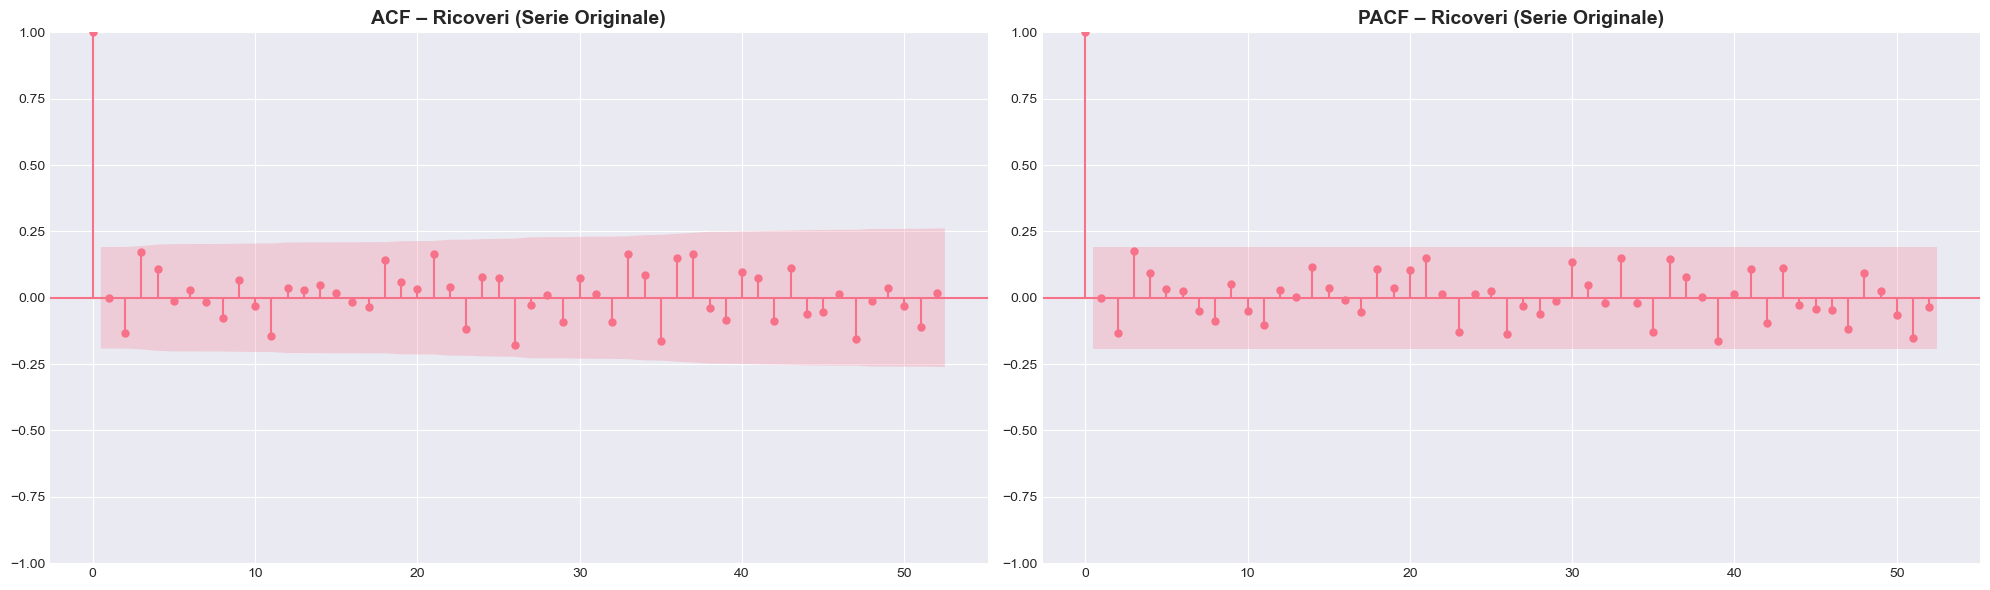

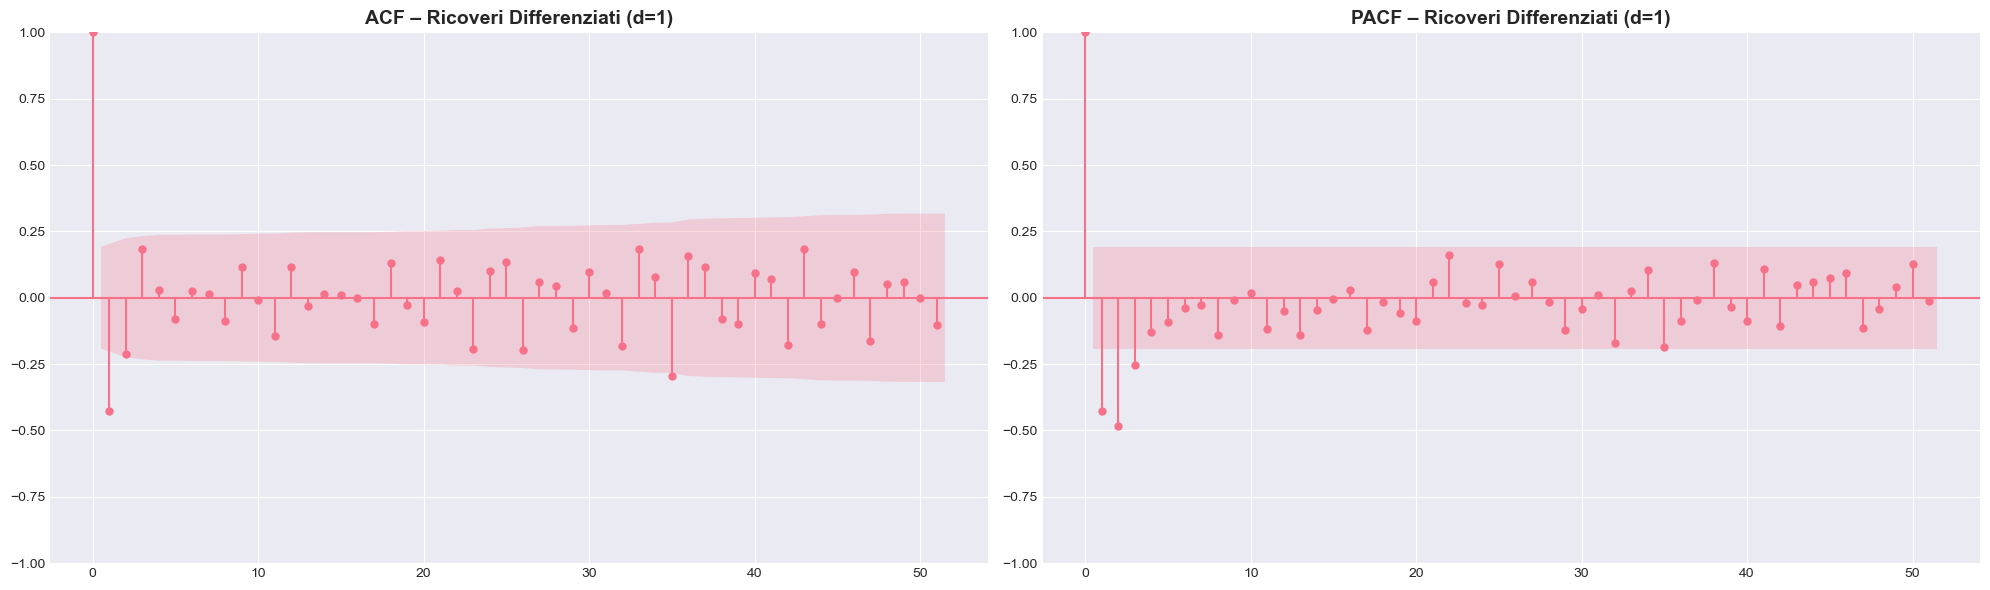

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi=100)
plot_acf(df_weekly['respiratory_admissions'].dropna(), lags=52, ax=axes[0])
axes[0].set_title('ACF – Ricoveri (Serie Originale)', fontsize=14, fontweight='bold')
plot_pacf(df_weekly['respiratory_admissions'].dropna(), lags=52, ax=axes[1])
axes[1].set_title('PACF – Ricoveri (Serie Originale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n_d1 = len(diff_series.dropna())
max_lags_d1 = min(52, n_d1 // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi=100)
plot_acf(diff_series.dropna(), lags=max_lags_d1, ax=axes[0])
axes[0].set_title('ACF – Ricoveri Differenziati (d=1)', fontsize=14, fontweight='bold')
plot_pacf(diff_series.dropna(), lags=max_lags_d1, ax=axes[1])
axes[1].set_title('PACF – Ricoveri Differenziati (d=1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




### 6.4 Selezione Parametri con `auto_arima` — Ricoveri


In [72]:
print("Ricerca parametri ottimali (può richiedere alcuni minuti)...\n")

# FIX: nome distinto per non sovrascrivere sarima_auto_pm della sezione 5
sarima_auto_adm = pm.auto_arima(
    df_weekly['respiratory_admissions'],
    seasonal=True, m=52,
    d=None, D=None,
    start_p=0, start_q=0,
    start_P=0, start_Q=0,
    max_p=2, max_q=2,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print("\n" + "─"*70)
print("MODELLO OTTIMALE TROVATO")
print("─"*70)
print(sarima_auto_adm.summary())

# best_order / best_seasonal per i Ricoveri (sezione 6)
best_order    = sarima_auto_adm.order
best_seasonal = sarima_auto_adm.seasonal_order
print(f"\nParametri ottimali Ricoveri: SARIMA{best_order} × {best_seasonal}")
print(f"AIC: {sarima_auto_adm.aic():.3f}")


Ricerca parametri ottimali (può richiedere alcuni minuti)...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1029.850, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=1011.212, Time=0.75 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1027.853, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=1009.697, Time=0.08 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=1011.216, Time=0.64 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=inf, Time=2.20 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=981.307, Time=0.09 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=983.305, Time=1.18 sec
 ARIMA(2,1,0)(0,0,1)[52] intercept   : AIC=983.306, Time=0.89 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=inf, Time=2.66 sec
 ARIMA(2,1,1)(0,0,0)[52] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[52]             : AIC=979.394, 

In [73]:
print("─"*70)
print("CONFRONTO AIC: auto_arima con d=0 vs auto_arima con d=1")
print("Nota: per ciascun d, p e q vengono riotimizzati → confronto equo.")
print("─"*70)

P_fix_adm, D_fix_adm, Q_fix_adm, s_fix_adm = best_seasonal

aic_results_adm = {}

for d_test in [0, 1]:
    try:
        m_tmp = pm.auto_arima(
            df_weekly['respiratory_admissions'],
            d=d_test,
            D=D_fix_adm,
            seasonal=True, m=s_fix_adm,
            start_p=0, start_q=0,
            start_P=0, start_Q=0,
            max_p=2, max_q=2,
            max_P=1, max_Q=1,
            stepwise=True,
            error_action='ignore',
            suppress_warnings=True,
            information_criterion='aic'
        )
        aic_results_adm[d_test] = m_tmp.aic()
        print(f"  d={d_test}  →  AIC = {m_tmp.aic():.2f}  |  ordine {m_tmp.order}×{m_tmp.seasonal_order}")
    except Exception as e:
        print(f"  d={d_test}  →  Errore: {e}")

if len(aic_results_adm) == 2:
    best_d_aic_adm = min(aic_results_adm, key=aic_results_adm.get)
    diff_aic_adm   = abs(aic_results_adm[0] - aic_results_adm[1])
    print(f"\n→ AIC migliore con d={best_d_aic_adm}  (differenza: {diff_aic_adm:.2f})")
    if best_d_aic_adm == 0:
        print("  La serie è stazionaria E d=0 ha AIC migliore → over-differenziazione confermata.")
    else:
        if diff_aic_adm < 2:
            print("  d=1 ha AIC leggermente migliore, ma la differenza < 2 è trascurabile.")
        else:
            print("  d=1 giustificato anche in termini di AIC nonostante la stazionarietà ADF.")


──────────────────────────────────────────────────────────────────────
CONFRONTO AIC: auto_arima con d=0 vs auto_arima con d=1
Nota: per ciascun d, p e q vengono riotimizzati → confronto equo.
──────────────────────────────────────────────────────────────────────
  d=0  →  AIC = 967.33  |  ordine (0, 0, 0)×(0, 0, 0, 52)
  d=1  →  AIC = 961.87  |  ordine (2, 1, 1)×(0, 0, 0, 52)

→ AIC migliore con d=1  (differenza: 5.46)
  d=1 giustificato anche in termini di AIC nonostante la stazionarietà ADF.


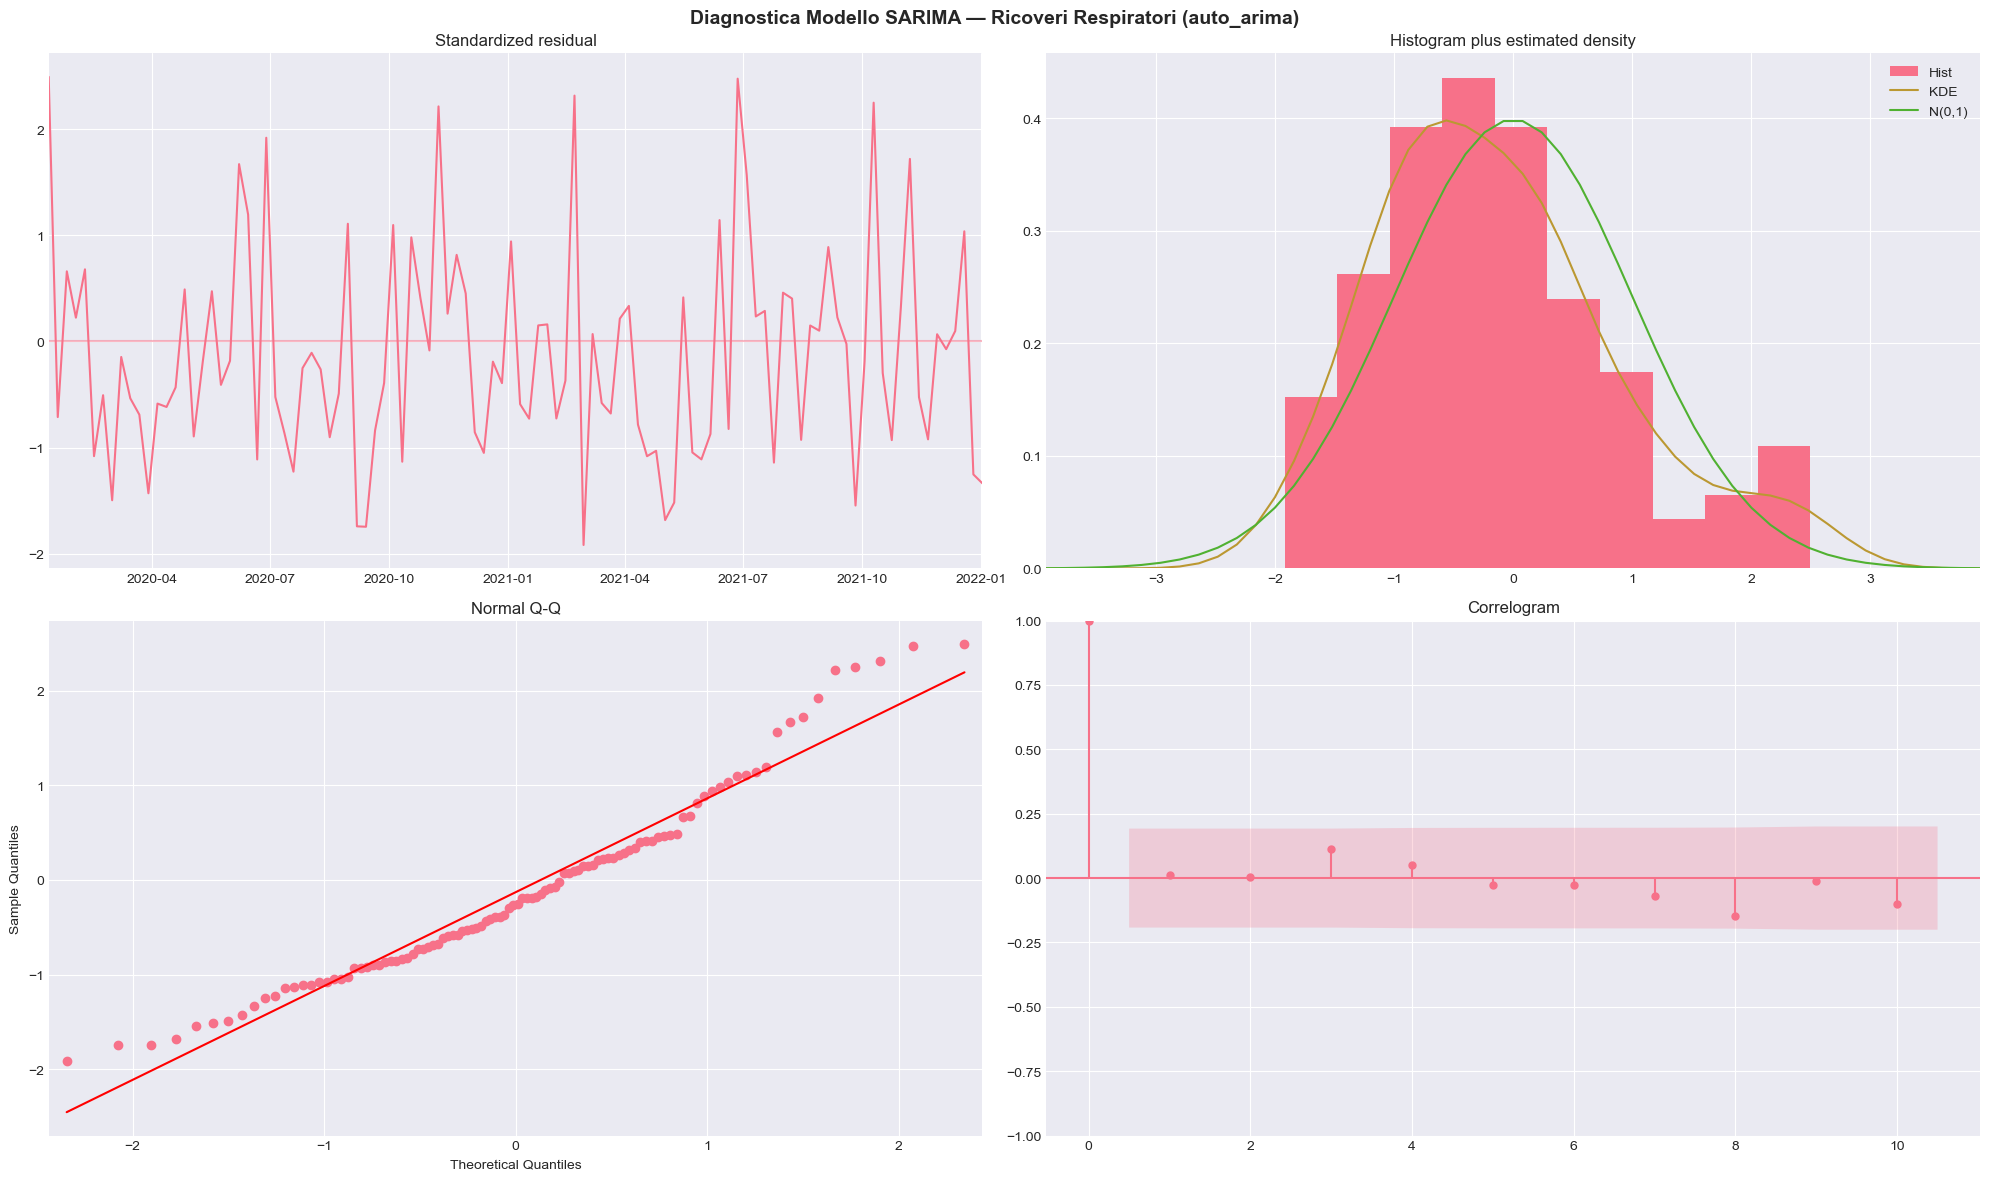

In [74]:
sarima_auto_adm.plot_diagnostics(figsize=(20, 12))
plt.suptitle('Diagnostica Modello SARIMA — Ricoveri Respiratori (auto_arima)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.5 Train/Test Split — Ricoveri


Training set: 2020-01-05 → 2021-08-08 (84 settimane)
Test set:     2021-08-15 → 2022-01-02 (21 settimane)
Split:        80.0% / 20.0%


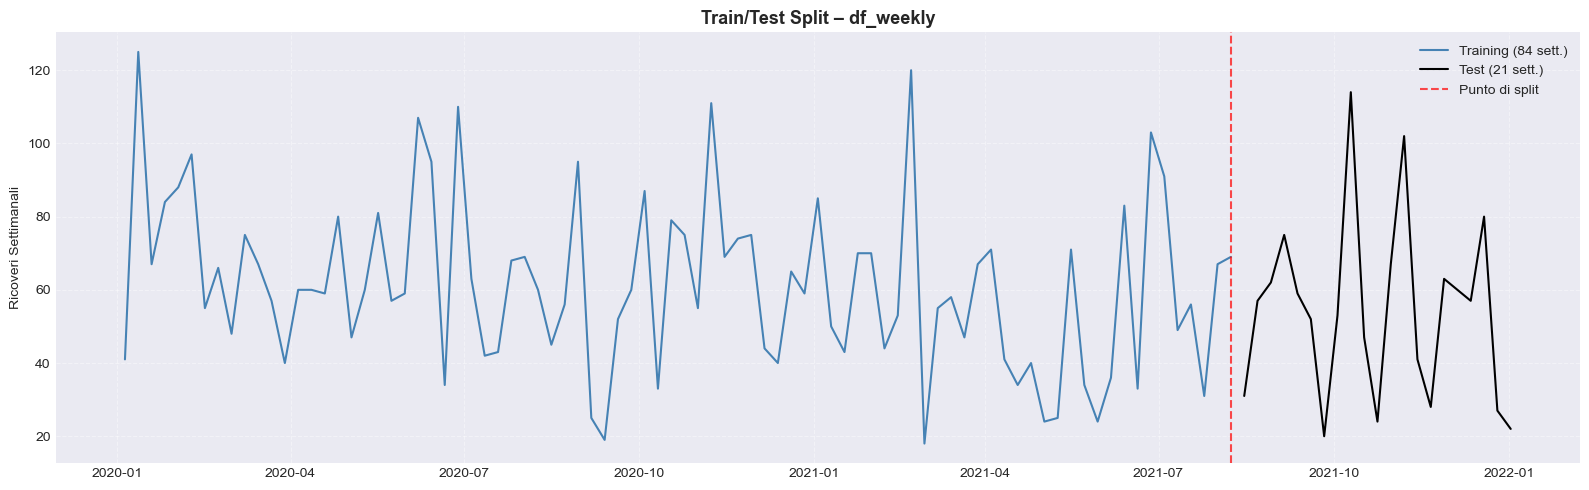

In [75]:
# FIX: split su df_weekly pulito (senza colonne ausiliarie year/month/season)
train_size = int(len(df_weekly) * 0.8)
train_w = df_weekly.iloc[:train_size].copy()
test_w  = df_weekly.iloc[train_size:].copy()

print(f"Training set: {train_w.index[0].date()} → {train_w.index[-1].date()} ({len(train_w)} settimane)")
print(f"Test set:     {test_w.index[0].date()} → {test_w.index[-1].date()} ({len(test_w)} settimane)")
print(f"Split:        {len(train_w)/len(df_weekly)*100:.1f}% / {len(test_w)/len(df_weekly)*100:.1f}%")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_w.index, train_w['respiratory_admissions'],
        label=f'Training ({len(train_w)} sett.)', color='steelblue')
ax.plot(test_w.index, test_w['respiratory_admissions'],
        label=f'Test ({len(test_w)} sett.)', color='black')
ax.axvline(train_w.index[-1], color='red', linestyle='--', alpha=0.7, label='Punto di split')
ax.set_title('Train/Test Split – df_weekly', fontsize=13, fontweight='bold')
ax.set_ylabel('Ricoveri Settimanali')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 6.6 Fit dei Modelli — Ricoveri

| Modello | Specifiche | Note |
|---------|------------|------|
| **A** | SARIMA(auto_arima) D=0 | Parametri ottimizzati sui ricoveri |
| **B** | SARIMA(2,1,0)×(0,0,0,52) | D=1 forzato; possibile non-convergenza |
| **C** | SARIMAX(auto) + PM2.5 lag1 + temp lag1 | Regressori laggati per evitare data leakage |


In [76]:
print("─"*70)
print(f"MODELLO A — SARIMA{best_order}×{best_seasonal} (da auto_arima, D=0)")
print("─"*70)

model_a = SARIMAX(
    train_w['respiratory_admissions'],
    order=best_order,
    seasonal_order=best_seasonal,
    trend='c' if best_order[1] == 0 else 'n'
)
fit_a = model_a.fit(disp=False)
print(fit_a.summary())

lb_a = acorr_ljungbox(fit_a.resid.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test:")
print(lb_a)

# Normalità residui
resid_a = fit_a.resid.dropna()
jb_stat, jb_p = jarque_bera(resid_a)
sw_stat, sw_p = shapiro(resid_a)
print(f"\nNormalità residui — Jarque-Bera: stat={jb_stat:.3f}, p={jb_p:.4f}")
print(f"Normalità residui — Shapiro-Wilk: stat={sw_stat:.3f}, p={sw_p:.4f}")
if jb_p > 0.05 and sw_p > 0.05:
    print("✓ Residui compatibili con normalità (entrambi i test: p > 0.05)")
else:
    print("⚠ Residui non normali — gli intervalli di confidenza potrebbero essere imprecisi.")

forecast_a = fit_a.get_forecast(steps=len(test_w))
pred_a = forecast_a.predicted_mean.reindex(test_w.index)
ci_a   = forecast_a.conf_int()
ci_a.index = test_w.index

# FIX: verifica esplicita con diagnostica degli indici
nan_count_a = pred_a.isna().sum()
if nan_count_a > 0:
    print(f"\n⚠ ERRORE: {nan_count_a} NaN dopo reindex. Confronto indici:")
    print("  Indice forecast:", forecast_a.predicted_mean.index[:3].tolist(), "...")
    print("  Indice test_w:", test_w.index[:3].tolist(), "...")
    raise AssertionError("Previsioni con NaN dopo reindex — indici non allineati.")

mae_a  = mean_absolute_error(test_w['respiratory_admissions'], pred_a)
rmse_a = np.sqrt(mean_squared_error(test_w['respiratory_admissions'], pred_a))
r2_a   = r2_score(test_w['respiratory_admissions'], pred_a)
print(f"\n>>> Modello A — MAE: {mae_a:.2f}  |  RMSE: {rmse_a:.2f}  |  R²: {r2_a:.3f}")
if r2_a < 0:
    print("  ⚠ R² negativo: il modello è peggiore di una previsione con la media.")


──────────────────────────────────────────────────────────────────────
MODELLO A — SARIMA(2, 1, 1)×(0, 0, 0, 52) (da auto_arima, D=0)
──────────────────────────────────────────────────────────────────────
                                 SARIMAX Results                                  
Dep. Variable:     respiratory_admissions   No. Observations:                   84
Model:                   SARIMAX(2, 1, 1)   Log Likelihood                -381.022
Date:                    Sun, 28 Jun 2026   AIC                            770.043
Time:                            22:57:00   BIC                            779.719
Sample:                        01-05-2020   HQIC                           773.930
                             - 08-08-2021                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [77]:
print("─"*70)
print("MODELLO B — SARIMA(2,1,0)×(1,1,0,52)  [D=1 forzato, scopo comparativo]")
print("NOTA: con 84 sett. di training, D=1 a s=52 lascia pochi gradi di libertà.")
print("⚠ I risultati di questo modello vanno interpretati con cautela estrema.")
print("─"*70)

model_b = SARIMAX(
    train_w['respiratory_admissions'],
    order=(2, 1, 0),
    seasonal_order=(1, 1, 0, 52),
    trend='n'
)
fit_b = model_b.fit(disp=False, maxiter=500)
print(fit_b.summary())

print("\n--- Verifica convergenza ---")
# FIX: flag booleano esplicito invece di dipendere dalla stringa con ⚠
b_converged = True
for param, se in zip(fit_b.params.index, fit_b.bse):
    if se > 50:
        print(f"⚠ {param}: std err = {se:.1f} — segnale di non-convergenza")
        b_converged = False
b_convergence_label = "OK" if b_converged else "NON CONVERGENTE"
print(f"Stato convergenza: {b_convergence_label}")

lb_b = acorr_ljungbox(fit_b.resid.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test:")
print(lb_b)

# Normalità residui
resid_b = fit_b.resid.dropna()
jb_stat, jb_p = jarque_bera(resid_b)
sw_stat, sw_p = shapiro(resid_b)
print(f"\nNormalità residui — Jarque-Bera: stat={jb_stat:.3f}, p={jb_p:.4f}")
print(f"Normalità residui — Shapiro-Wilk: stat={sw_stat:.3f}, p={sw_p:.4f}")

forecast_b = fit_b.get_forecast(steps=len(test_w))
pred_b = forecast_b.predicted_mean.reindex(test_w.index)
ci_b   = forecast_b.conf_int()
ci_b.index = test_w.index

# FIX: verifica esplicita con diagnostica degli indici
nan_count_b = pred_b.isna().sum()
if nan_count_b > 0:
    print(f"\n⚠ ERRORE: {nan_count_b} NaN dopo reindex. Confronto indici:")
    print("  Indice forecast:", forecast_b.predicted_mean.index[:3].tolist(), "...")
    print("  Indice test_w:", test_w.index[:3].tolist(), "...")
    raise AssertionError("Previsioni con NaN dopo reindex — indici non allineati.")

mae_b  = mean_absolute_error(test_w['respiratory_admissions'], pred_b)
rmse_b = np.sqrt(mean_squared_error(test_w['respiratory_admissions'], pred_b))
r2_b   = r2_score(test_w['respiratory_admissions'], pred_b)
print(f"\n>>> Modello B — MAE: {mae_b:.2f}  |  RMSE: {rmse_b:.2f}  |  R²: {r2_b:.3f}")
if r2_b < 0:
    print("  ⚠ R² negativo: il modello è peggiore di una previsione con la media.")


──────────────────────────────────────────────────────────────────────
MODELLO B — SARIMA(2,1,0)×(1,1,0,52)  [D=1 forzato, scopo comparativo]
NOTA: con 84 sett. di training, D=1 a s=52 lascia pochi gradi di libertà.
⚠ I risultati di questo modello vanno interpretati con cautela estrema.
──────────────────────────────────────────────────────────────────────
                                     SARIMAX Results                                      
Dep. Variable:             respiratory_admissions   No. Observations:                   84
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 52)   Log Likelihood                -152.519
Date:                            Sun, 28 Jun 2026   AIC                            313.038
Time:                                    22:57:24   BIC                            318.774
Sample:                                01-05-2020   HQIC                           314.908
                                     - 08-08-2021                                         
Cova

In [78]:
print("─"*70)
print(f"MODELLO C — SARIMAX{best_order}×{best_seasonal} con PM2.5(lag1) + temperatura(lag1)")
print("FIX: regressori laggati di 1 settimana per evitare data leakage.")
print("─"*70)

exog_vars = ['PM2.5', 'temperature']

# 1. Costruiamo il DataFrame con y e i regressori laggati nello stesso oggetto
#    così il dropna() è congiunto e non può sfasare le serie.
df_c = df_weekly[['respiratory_admissions'] + exog_vars].copy()
df_c[exog_vars] = df_c[exog_vars].shift(1)   # lag 1
df_c = df_c.dropna()                           # rimuove la prima riga (lag NaN)

# 2. Split: usiamo le stesse date del train/test set originale
#    ma filtriamo su df_c (che ha una riga in meno per il lag)
train_c = df_c[df_c.index <= train_w.index[-1]]
test_c  = df_c[df_c.index > train_w.index[-1]]

assert len(train_c) > 0 and len(test_c) > 0, "Split vuoto dopo il lag!"
print(f"Training dopo lag: {len(train_c)} settimane  |  Test: {len(test_c)} settimane")

# 3. Standardizzazione: fit su train, transform su entrambi
scaler = StandardScaler()
train_X = pd.DataFrame(
    scaler.fit_transform(train_c[exog_vars]),
    columns=exog_vars, index=train_c.index
)
test_X = pd.DataFrame(
    scaler.transform(test_c[exog_vars]),
    columns=exog_vars, index=test_c.index
)
train_y = train_c['respiratory_admissions']
test_y  = test_c['respiratory_admissions']

# Verifica allineamento
assert (train_X.index == train_y.index).all(), "Indici train_X e train_y non allineati!"
assert (test_X.index == test_y.index).all(),   "Indici test_X e test_y non allineati!"

model_c = SARIMAX(
    train_y,
    exog=train_X,
    order=best_order,
    seasonal_order=best_seasonal,
    trend='c' if best_order[1] == 0 else 'n'
)
fit_c = model_c.fit(disp=False)
print(fit_c.summary())

print("\n--- Significatività variabili esogene (standardizzate) ---")
for var in exog_vars:
    try:
        pval = fit_c.pvalues[var]
        sig = '✓ significativa (p < 0.05)' if pval < 0.05 else f'✗ NON significativa (p={pval:.3f})'
        print(f"  {var} (lag1): p-value = {pval:.4f}  →  {sig}")
    except KeyError:
        print(f"  {var}: parametro non trovato nel summary")

lb_c = acorr_ljungbox(fit_c.resid.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test:")
print(lb_c)

# Normalità residui
resid_c = fit_c.resid.dropna()
jb_stat, jb_p = jarque_bera(resid_c)
sw_stat, sw_p = shapiro(resid_c)
print(f"\nNormalità residui — Jarque-Bera: stat={jb_stat:.3f}, p={jb_p:.4f}")
print(f"Normalità residui — Shapiro-Wilk: stat={sw_stat:.3f}, p={sw_p:.4f}")

forecast_c = fit_c.get_forecast(steps=len(test_y), exog=test_X)
pred_c = forecast_c.predicted_mean.reindex(test_y.index)
ci_c   = forecast_c.conf_int()
ci_c.index = test_y.index
nan_count_c = pred_c.isna().sum()
if nan_count_c > 0:
    print(f"\n⚠ ERRORE: {nan_count_c} NaN dopo reindex. Confronto indici:")
    print("  Indice forecast:", forecast_c.predicted_mean.index[:3].tolist(), "...")
    print("  Indice test_y:", test_y.index[:3].tolist(), "...")
    raise AssertionError("Previsioni Modello C con NaN dopo reindex — indici non allineati.")

mae_c  = mean_absolute_error(test_y, pred_c)
rmse_c = np.sqrt(mean_squared_error(test_y, pred_c))
r2_c   = r2_score(test_y, pred_c)
print(f"\n>>> Modello C — MAE: {mae_c:.2f}  |  RMSE: {rmse_c:.2f}  |  R²: {r2_c:.3f}")
if r2_c < 0:
    print("  ⚠ R² negativo: il modello è peggiore di una previsione con la media.")

# Aggiorna test_w_c per uso nel confronto visivo (potrebbe avere 1 riga in meno)
test_w_c = test_c  # salviamo per la cella di confronto


──────────────────────────────────────────────────────────────────────
MODELLO C — SARIMAX(2, 1, 1)×(0, 0, 0, 52) con PM2.5(lag1) + temperatura(lag1)
FIX: regressori laggati di 1 settimana per evitare data leakage.
──────────────────────────────────────────────────────────────────────
Training dopo lag: 83 settimane  |  Test: 21 settimane
                                 SARIMAX Results                                  
Dep. Variable:     respiratory_admissions   No. Observations:                   83
Model:                   SARIMAX(2, 1, 1)   Log Likelihood                -375.830
Date:                    Sun, 28 Jun 2026   AIC                            763.660
Time:                            22:57:24   BIC                            778.100
Sample:                        01-12-2020   HQIC                           769.458
                             - 08-08-2021                                         
Covariance Type:                      opg                                     

### 6.7 Confronto Visivo delle Previsioni — Ricoveri


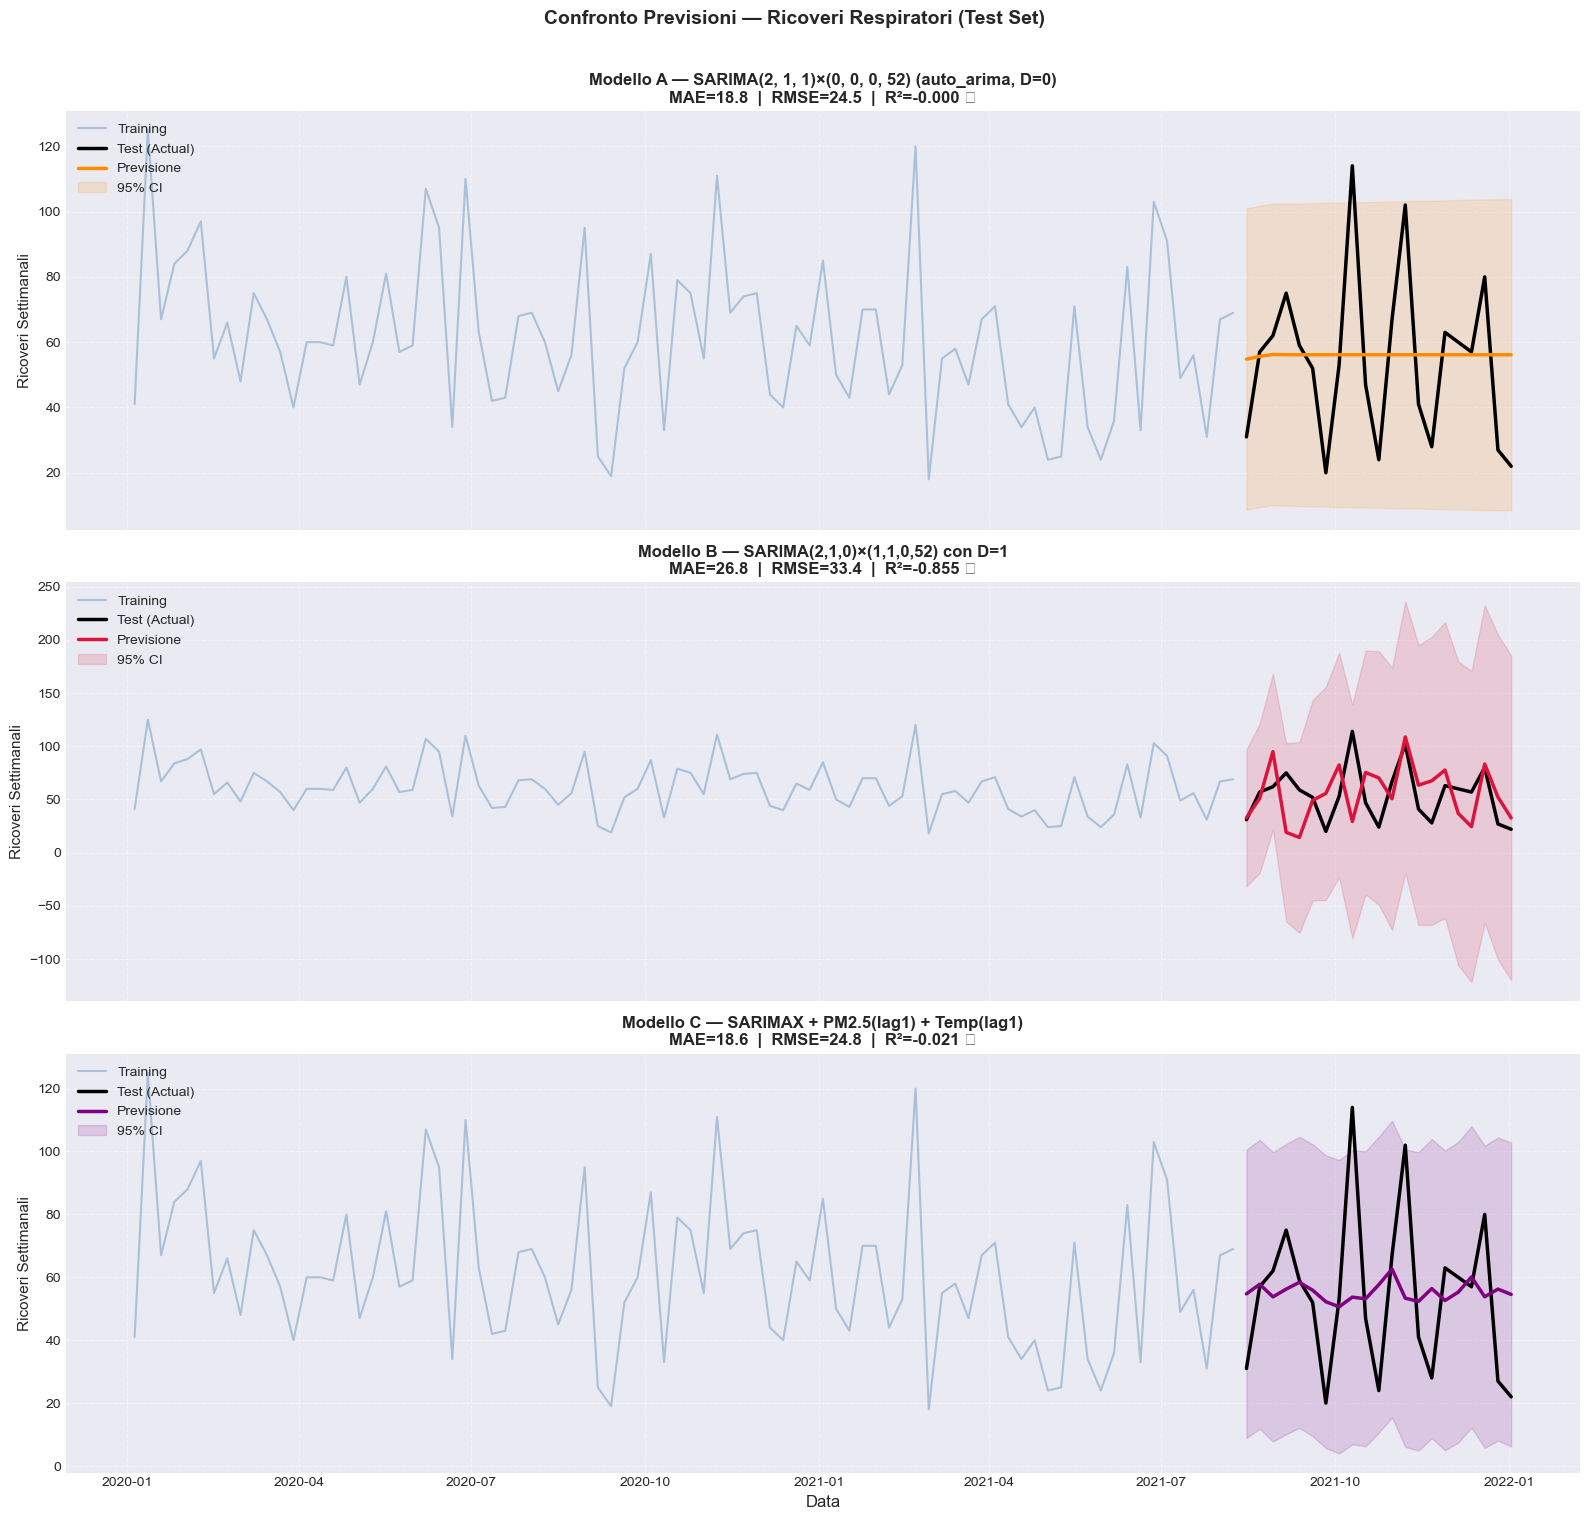

In [79]:
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

configs = [
    (pred_a, ci_a,  test_w,   test_w['respiratory_admissions'],
     f'Modello A — SARIMA{best_order}×{best_seasonal} (auto_arima, D=0)',
     'darkorange', mae_a, rmse_a, r2_a),
    (pred_b, ci_b,  test_w,   test_w['respiratory_admissions'],
     'Modello B — SARIMA(2,1,0)×(1,1,0,52) con D=1',
     'crimson', mae_b, rmse_b, r2_b),
    (pred_c, ci_c,  test_w_c, test_w_c['respiratory_admissions'],
     f'Modello C — SARIMAX + PM2.5(lag1) + Temp(lag1)',
     'purple', mae_c, rmse_c, r2_c),
]

for ax, (pred, ci, tw, actual, label, color, mae, rmse, r2) in zip(axes, configs):
    ax.plot(train_w.index, train_w['respiratory_admissions'],
            label='Training', color='steelblue', alpha=0.4, linewidth=1.5)
    ax.plot(tw.index, actual,
            label='Test (Actual)', color='black', linewidth=2.5)
    ax.plot(pred.index, pred,
            label='Previsione', color=color, linewidth=2.5)
    if ci is not None:
        ax.fill_between(pred.index, ci.iloc[:, 0], ci.iloc[:, 1],
                        color=color, alpha=0.15, label='95% CI')
    r2_str = f"{r2:.3f}" + (" ⚠" if r2 < 0 else "")
    ax.set_title(f'{label}\nMAE={mae:.1f}  |  RMSE={rmse:.1f}  |  R²={r2_str}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Ricoveri Settimanali', fontsize=11)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Data', fontsize=12)
plt.suptitle('Confronto Previsioni — Ricoveri Respiratori (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 6.8 Tabella Comparativa Finale — Ricoveri


In [80]:
lbp_a = acorr_ljungbox(fit_a.resid.dropna(), lags=[10], return_df=True)['lb_pvalue'].values[0]
lbp_b = acorr_ljungbox(fit_b.resid.dropna(), lags=[10], return_df=True)['lb_pvalue'].values[0]
lbp_c = acorr_ljungbox(fit_c.resid.dropna(), lags=[10], return_df=True)['lb_pvalue'].values[0]

results = pd.DataFrame({
    f'A – SARIMA{best_order}×{best_seasonal}': {
        'MAE': round(mae_a, 2), 'RMSE': round(rmse_a, 2), 'R²': round(r2_a, 3),
        'AIC (train)': round(fit_a.aic, 1), 'Ljung-Box p (lag10)': round(lbp_a, 4),
        'Convergenza': 'OK',
        '_converged': True,  # flag interno per selezione robusta
    },
    'B – SARIMA(2,1,0)×(1,1,0,52)': {
        'MAE': round(mae_b, 2), 'RMSE': round(rmse_b, 2), 'R²': round(r2_b, 3),
        'AIC (train)': round(fit_b.aic, 1), 'Ljung-Box p (lag10)': round(lbp_b, 4),
        'Convergenza': b_convergence_label,
        '_converged': b_converged,  # FIX: flag booleano, non stringa con ⚠
    },
    'C – SARIMAX + PM2.5(lag1) + Temp(lag1)': {
        'MAE': round(mae_c, 2), 'RMSE': round(rmse_c, 2), 'R²': round(r2_c, 3),
        'AIC (train)': round(fit_c.aic, 1), 'Ljung-Box p (lag10)': round(lbp_c, 4),
        'Convergenza': 'OK',
        '_converged': True,
    },
}).T

# Colonna interna usata solo per la logica, non stampata
convergence_flags = results.pop('_converged')

print("="*80)
print("TABELLA COMPARATIVA FINALE — Metriche sul Test Set")
print("="*80)
print(results.to_string())

best_model = results['MAE'].astype(float).idxmin()
print(f"\n→ Modello con MAE minore: {best_model}")

# FIX: uso flag booleano invece di cercare '⚠' nel nome del modello
if not convergence_flags[best_model]:
    print("  ⚠ Il modello migliore per MAE (B) non ha convergito: risultato inaffidabile.")
    reliable_mask = convergence_flags.astype(bool)
    if reliable_mask.any():
        best_reliable = results.loc[reliable_mask, 'MAE'].astype(float).idxmin()
        print(f"  → Miglior modello affidabile: {best_reliable}")
    else:
        print("  → Nessun modello affidabile disponibile.")


TABELLA COMPARATIVA FINALE — Metriche sul Test Set
                                          MAE   RMSE     R² AIC (train) Ljung-Box p (lag10)      Convergenza
A – SARIMA(2, 1, 1)×(0, 0, 0, 52)       18.76  24.54   -0.0       770.0              0.4906               OK
B – SARIMA(2,1,0)×(1,1,0,52)            26.81  33.42 -0.855       313.0              0.5009  NON CONVERGENTE
C – SARIMAX + PM2.5(lag1) + Temp(lag1)  18.56   24.8 -0.021       763.7              0.7904               OK

→ Modello con MAE minore: C – SARIMAX + PM2.5(lag1) + Temp(lag1)


### 6.9 Forecasting Fuori Campione — Ricoveri Respiratori

Previsione delle **prossime 4 settimane** oltre l'ultimo dato disponibile, con tutti e tre i modelli.  
Il modello C (SARIMAX) richiede i regressori esogeni futuri: vengono usati i valori medi del test set come proxy prudenziale (scenario medio), con relativo intervallo di confidenza ampliato.


FORECASTING FUORI CAMPIONE — 4 settimane future
Periodo: 2022-01-09 → 2022-01-30

Modello A — SARIMA(2, 1, 1)×(0, 0, 0, 52) (full fit):
  2022-01-09  →  62.3  [95% CI: 16.3 – 108.2]
  2022-01-16  →  60.4  [95% CI: 14.5 – 106.4]
  2022-01-23  →  52.4  [95% CI: 6.0 – 98.8]
  2022-01-30  →  53.3  [95% CI: 6.8 – 99.8]

Modello B — SARIMA(2,1,0)×(1,1,0,52) [D=1 forzato — interpretare con cautela]:
  2022-01-09  →  105.9  [95% CI: 103.2 – 108.7]
  2022-01-16  →  48.0  [95% CI: 44.8 – 51.1]
  2022-01-23  →  65.0  [95% CI: 62.1 – 67.8]
  2022-01-30  →  69.0  [95% CI: 65.7 – 72.2]

Modello C — SARIMAX + PM2.5(lag1) + Temp(lag1) [esogene future = media test set]:
  2022-01-09  →  61.2  [95% CI: 15.3 – 107.1]
  2022-01-16  →  60.0  [95% CI: 14.0 – 105.9]
  2022-01-23  →  52.1  [95% CI: 5.8 – 98.3]
  2022-01-30  →  52.7  [95% CI: 6.3 – 99.1]


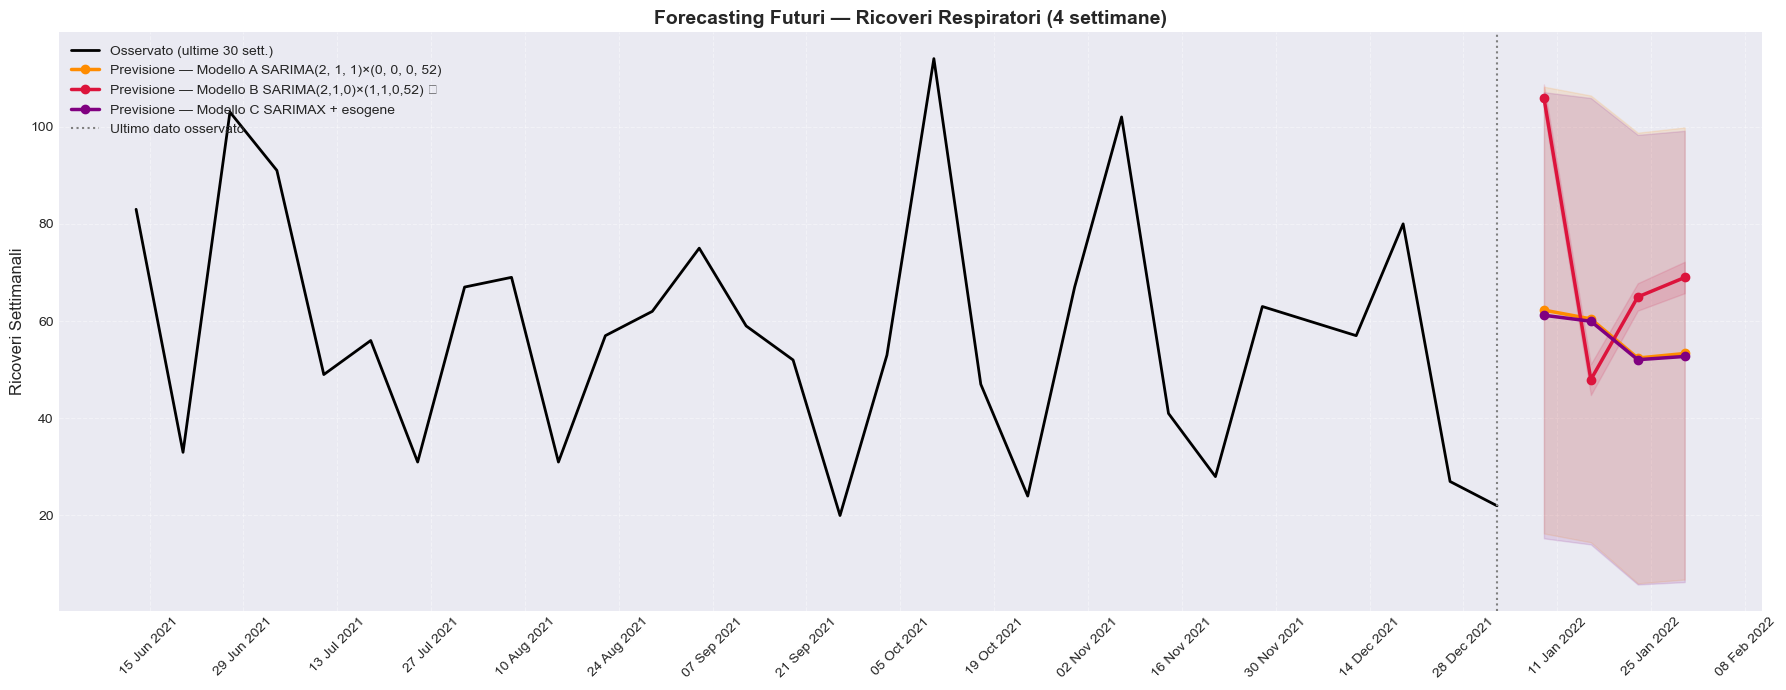

In [81]:
N_FUTURE = 4  # settimane da prevedere oltre l'ultimo dato

# Indice futuro: 4 settimane dopo l'ultima data del dataset
last_date   = df_weekly.index[-1]
# FIX: uso pd.date_range con freq='W' ancorato all'ultima data per evitare
# disallineamenti se last_date non cade esattamente di domenica.
future_idx  = pd.date_range(start=last_date, periods=N_FUTURE + 1, freq='W')[1:]

print("="*70)
print(f"FORECASTING FUORI CAMPIONE — {N_FUTURE} settimane future")
print(f"Periodo: {future_idx[0].date()} → {future_idx[-1].date()}")
print("="*70)

# ── Modello A (SARIMA puro) ──────────────────────────────────────────────────
# Ri-fittiamo sull'intera serie per sfruttare tutte le osservazioni disponibili
model_a_full = SARIMAX(
    df_weekly['respiratory_admissions'],
    order=best_order,
    seasonal_order=best_seasonal,
    trend='c' if best_order[1] == 0 else 'n'
)
fit_a_full = model_a_full.fit(disp=False)

fc_a = fit_a_full.get_forecast(steps=N_FUTURE)
pred_future_a = fc_a.predicted_mean
pred_future_a.index = future_idx
ci_future_a   = fc_a.conf_int()
ci_future_a.index = future_idx
print(f"\nModello A — SARIMA{best_order}×{best_seasonal} (full fit):")
for dt, val, lo, hi in zip(future_idx,
                            pred_future_a,
                            ci_future_a.iloc[:, 0],
                            ci_future_a.iloc[:, 1]):
    print(f"  {dt.date()}  →  {val:.1f}  [95% CI: {lo:.1f} – {hi:.1f}]")

# ── Modello B (SARIMA D=1) ───────────────────────────────────────────────────
model_b_full = SARIMAX(
    df_weekly['respiratory_admissions'],
    order=(2, 1, 0),
    seasonal_order=(1, 1, 0, 52),
    trend='n'
)
fit_b_full = model_b_full.fit(disp=False, maxiter=500)

fc_b = fit_b_full.get_forecast(steps=N_FUTURE)
pred_future_b = fc_b.predicted_mean
pred_future_b.index = future_idx
ci_future_b   = fc_b.conf_int()
ci_future_b.index = future_idx
print(f"\nModello B — SARIMA(2,1,0)×(1,1,0,52) [D=1 forzato — interpretare con cautela]:")
for dt, val, lo, hi in zip(future_idx,
                            pred_future_b,
                            ci_future_b.iloc[:, 0],
                            ci_future_b.iloc[:, 1]):
    print(f"  {dt.date()}  →  {val:.1f}  [95% CI: {lo:.1f} – {hi:.1f}]")

# ── Modello C (SARIMAX con esogene) ─────────────────────────────────────────
# FIX: ri-fittiamo lo scaler sull'intero df_c (train + test) prima del full-fit,
# così le statistiche di normalizzazione sono coerenti con tutti i dati usati.
scaler_full = StandardScaler()
scaler_full.fit(df_c[exog_vars])

model_c_full = SARIMAX(
    df_c['respiratory_admissions'],
    exog=pd.DataFrame(
        scaler_full.transform(df_c[exog_vars]),
        columns=exog_vars, index=df_c.index
    ),
    order=best_order,
    seasonal_order=best_seasonal,
    trend='c' if best_order[1] == 0 else 'n'
)
fit_c_full = model_c_full.fit(disp=False)

# Proxy esogene future: media del test set (scenario medio prudenziale)
exog_future_raw = pd.DataFrame(
    np.tile(test_c[exog_vars].mean().values, (N_FUTURE, 1)),
    columns=exog_vars,
    index=future_idx
)
exog_future_scaled = pd.DataFrame(
    scaler_full.transform(exog_future_raw),
    columns=exog_vars, index=future_idx
)

fc_c = fit_c_full.get_forecast(steps=N_FUTURE, exog=exog_future_scaled)
pred_future_c = fc_c.predicted_mean
pred_future_c.index = future_idx
ci_future_c   = fc_c.conf_int()
ci_future_c.index = future_idx
print(f"\nModello C — SARIMAX + PM2.5(lag1) + Temp(lag1) [esogene future = media test set]:")
for dt, val, lo, hi in zip(future_idx,
                            pred_future_c,
                            ci_future_c.iloc[:, 0],
                            ci_future_c.iloc[:, 1]):
    print(f"  {dt.date()}  →  {val:.1f}  [95% CI: {lo:.1f} – {hi:.1f}]")

# ── Grafico confronto previsioni future ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))

# Ultimi 30 punti osservati come contesto
context = df_weekly['respiratory_admissions'].iloc[-30:]
ax.plot(context.index, context, color='black', linewidth=2,
        label='Osservato (ultime 30 sett.)')

configs_future = [
    (pred_future_a, ci_future_a, f'Modello A SARIMA{best_order}×{best_seasonal}', 'darkorange'),
    (pred_future_b, ci_future_b, 'Modello B SARIMA(2,1,0)×(1,1,0,52) ⚠',        'crimson'),
    (pred_future_c, ci_future_c, 'Modello C SARIMAX + esogene',                   'purple'),
]

for pred, ci, label, color in configs_future:
    ax.plot(pred.index, pred, color=color, linewidth=2.5,
            marker='o', markersize=6, label=f'Previsione — {label}')
    ax.fill_between(pred.index, ci.iloc[:, 0], ci.iloc[:, 1],
                    color=color, alpha=0.12)

ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.5, label='Ultimo dato osservato')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)
ax.set_title(f'Forecasting Futuri — Ricoveri Respiratori ({N_FUTURE} settimane)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Ricoveri Settimanali', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

